# FR5 — Paid services rendered to the population: structural econometric analysis and forecast to 2030

**MIIS module 15.5.2 — Microeconomic analysis and forecasting.** Ministry of Economy of the Republic of Azerbaijan.

## The task

> *"Əhaliyə göstərilən pullu xidmətlərin **həcmi** və **artım sürətinin** təhlili və proqnozlaşdırılması."*

Analysis and forecasting of the **volume** and the **growth rate** of paid services rendered to the
population, five years ahead (2026–2030).

## Constraints set by the requester

- **No autoregressive models.** No AR, ARIMA, ARCH or GARCH. Part 9 states exactly which lag
  constructs appear and why each is an accounting identity or an inference device rather than an
  autoregression.
- **Structural econometric models only**, so that the effect of related sectors and markets is visible.
- **Where the workbook lacks data, collect it from the State Statistical Committee (DSK).**
- Five-year horizon, 2026–2030.

## What "structural" means for this object

Paid services rendered to the population are **household consumption of services**. The structural
model of that object is not a time-series relation but a **demand system**: households allocate a
budget across services according to their real income and relative prices, subject to an adding-up
constraint. FR5 is therefore built as a two-tier demand system:

1. **How much** — an aggregate demand equation for the real volume of paid services per head, driven
   by real household income per head and the relative price of services. This is an Engel relation at
   the aggregate level, and it delivers the *həcm* (volume) and its *artım sürəti* (growth rate).
2. **Of what** — a share system across the **thirteen published types of service** (household,
   transport, communication, housing, utilities, culture, tourism, sport, medical, sanatoria, legal and
   banking, education, other), in the form of a linear-approximate almost-ideal demand system
   (LA-AIDS) written in log-odds so that predicted shares are always positive and always sum to one.
   The expenditure coefficients of that system *are* the Engel elasticities, which is the answer to how
   the market for each service responds to income growth.

Two further cuts are then modelled, because the published data support them: services supplied by
**legal entities versus individual entrepreneurs**, and services supplied by the **state versus the
non-state sector**.

## Why data had to be collected from DSK

The workbook contains the **total** value of paid services and its growth rate (1990–2025) and the
provider split, but **no breakdown by type of service at all**. Without that breakdown there is no
demand system and no way to say which services grow and why. The DSK *Paid Services* tables supply the
thirteen-type decomposition for 1995–2025 in value and 2006–2025 in volume. Part 4 collects and
validates them; every one of the thirty-one years reproduces the published total exactly.

## The single most useful thing found in the data

Part 5 establishes that the **implicit deflator of the published paid-services series is exactly the
workbook's paid-services consumer price index** — agreement to 0.04 index points in every one of
nineteen overlapping years. The price side of this market is therefore *observed*, not estimated. That
closes the nominal–real–price triple exactly, and it means FR5 can model the volume structurally and
obtain the nominal value by identity rather than by a second, separately-estimated equation.

## Relation to FR1, FR3 and FR4

| Deliverable | Object | Supplies FR5 with |
|---|---|---|
| **FR1** | Sector output, prices, the macro economy | Real household disposable income, population, the paid-services deflator, and the aggregate paid-services series — history and 2026–2030 forecast, three scenarios |
| **FR3** | Average monthly wages | Household income context |
| **FR4** | Employment | Employment in the service activities that supply these services |
| **FR5** *(this notebook)* | **Volume and growth of paid services** | — |

Part 16 verifies that FR5's aggregate path is consistent with FR1's, since FR1 already forecasts this
series; FR5's contribution is the structural demand system behind it and the thirteen-type breakdown
underneath it.

| Part | Content |
|---|---|
| 1–2 | Purpose; environment and reproducibility |
| 3 | What the workbook holds, and the gap |
| 4 | Collecting and validating the DSK paid-services tables |
| 5 | The deflator identity, and construction of volumes by type |
| 6 | Data-integrity findings |
| 7 | The structure to be explained |
| 8 | Econometric toolkit |
| 9 | Permitted lag constructs; specifications tested and rejected |
| 10 | Tier 1 — aggregate demand for paid services |
| 11 | Tier 2 — the thirteen-type demand system |
| 12 | Provider and ownership splits |
| 13 | Regional cross-check |
| 14 | Solving the model |
| 15 | Ex-post hold-out validation |
| 16 | Baseline forecast 2026–2030: volume and growth rates |
| 17 | Scenarios and levers |
| 18 | Identity checks, exports, findings and limitations |

## Part 2 — Environment and reproducibility

Three inputs: the workbook, the DSK paid-services files in `data/dsk_services/` (downloaded on first
run and then read from disk), and the FR1 result files in `output/`. No random numbers enter any
estimate; the single seed is used only by the Part 8 self-test of the estimator toolkit.

In [1]:
%matplotlib inline
import os, sys, json, math, re, warnings, unicodedata, urllib.request
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats, optimize
import matplotlib, matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 20260927
pd.set_option('display.width', 220, 'display.max_columns', 60,
              'display.float_format', lambda v: f'{v:,.3f}')
plt.rcParams.update({'figure.figsize': (12, 5.5), 'figure.dpi': 110, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False, 'legend.frameon': False})
PAL = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2',
       '#7f7f7f', '#bcbd22', '#17becf', '#393b79', '#b5cf6b', '#a55194']

BASE = Path('/Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit')
XL   = BASE / 'data' / 'Statistik data dinamika 05.06.2026 +.xlsx'
SDIR = BASE / 'data' / 'dsk_services'
OUT  = BASE / 'output'
OUT.mkdir(exist_ok=True); SDIR.mkdir(parents=True, exist_ok=True)

LAST_ACT = 2025                       # last actual year, on every series FR5 uses
FC_YEARS = list(range(2026, 2031))
BASE_YR  = 2015                       # price base for real levels, as in FR1
DENOM    = 1995                       # nominal levels are comparable only from this year (Part 6, F1)

print('python     ', sys.version.split()[0])
for m in ['numpy', 'pandas', 'matplotlib', 'openpyxl', 'xlrd', 'statsmodels', 'scipy']:
    try:
        mod = __import__(m); print(f'{m:<12}', getattr(mod, '__version__', 'n/a'))
    except ImportError:
        print(f'{m:<12} NOT INSTALLED')
print()
print('workbook       :', XL.exists(), f'{XL.stat().st_size/1e6:.2f} MB' if XL.exists() else '')
print('last actual    :', LAST_ACT, '| forecast', FC_YEARS, '| price base', BASE_YR)

python      3.14.7
numpy        2.4.2
pandas       2.3.3
matplotlib   3.11.1


openpyxl     3.1.5
xlrd         2.0.2
statsmodels  0.14.6
scipy        1.18.1

workbook       : True 3.43 MB
last actual    : 2025 | forecast [2026, 2027, 2028, 2029, 2030] | price base 2015


### 2.1 Azerbaijani case folding

Two casing traps matter for matching the workbook's Azerbaijani row labels.
`'İ'.lower()` returns `'i'` **followed by U+0307 COMBINING DOT ABOVE**, which does not compare equal to
a typed `'i'`, so the combining mark must be folded. But `'I'.lower()` returns `'i'`, **not** the
dotless `'ı'`, so folding `'ı'` would destroy the distinction in words such as *xidmətlərin*, *pullu*
and *artım* — the very words this notebook matches on. `az_lower` folds the first and preserves the
second; the assertions below prevent a future edit from reintroducing either trap.

In [2]:
# Lower-case an Azerbaijani label, folding the combining dot but preserving dotless i.
def az_lower(s):
    return unicodedata.normalize('NFC', str(s).lower().replace('̇', ''))

assert az_lower('İqtisadiyyat') == 'iqtisadiyyat'
assert az_lower('Xidmətlərin') == 'xidmətlərin'
assert az_lower('ARTIM') == 'artim'            # ASCII I lowers to i, not to dotless i
assert az_lower('artım') == 'artım'            # a genuine dotless i survives
assert 'pullu' in az_lower('Əhaliyə göstərilən PULLU xidmətlər'.replace('PULLU', 'pullu'))
assert 'ı' in az_lower('Əhalinin sayı')
print('az_lower: both casing traps covered by assertions')

az_lower: both casing traps covered by assertions


## Part 3 — What the workbook holds, and the gap

| Workbook location | Content | Years |
|---|---|---|
| `Sosial sektor ` r27 / r28 | **Value of paid services rendered to the population**; its real growth index | 1990–2025 |
| `Sosial sektor ` r29 / r30 | Value supplied by **legal entities**; real growth | 1995–2025 |
| `Sosial sektor ` r31 / r32 | Value supplied in the **non-state sector**; real growth | 1995–2025 |
| `Sosial sektor ` r33 / r34 | Value supplied by **individual entrepreneurs**; real growth | 1995–2025 |
| `Sosial sektor ` r35 / r36 | Population nominal income, total and per head per month | 1997–2025 |
| `Monetar sektoru` r89 / r93 | **Paid-services consumer price index**, 12-month and average annual | 2000–2025 |
| `Regionlar`…`Regionlar 13` r100 | Real growth of services by 14 economic regions | 2021–2025 |

That is a strong aggregate dataset — thirty-six years of the headline series, and both a value and a
volume measure. **What it does not contain anywhere is a breakdown by type of service.** There is no
row for transport services, communication services, utilities, medical or educational services supplied
to households. Without that, the demand system that constitutes the structural content of this task
cannot be written down, and the question of *which* services will grow cannot be answered at all.

The cell below reads the workbook rows and confirms the coverage from the file rather than asserting it.

In [3]:
_BLANK = {'', '-', '–', '—', '...', '..', 'x', 'n/a'}

def to_num(v):
    # The DSK service tables store some cells as TEXT with non-breaking-space thousands separators
    # and a comma decimal mark, e.g. '4\xa0088\xa0188,1'. Reading them as floats silently yields NaN
    # for 2009, 2014 and 2016-2022 in table 7.1, so every numeric read goes through this parser.
    if v is None or isinstance(v, bool):
        return np.nan
    if isinstance(v, (int, float)):
        return np.nan if (isinstance(v, float) and np.isnan(v)) else float(v)
    t = str(v).replace('\xa0', '').replace(' ', '').replace(' ', '').strip()
    if t in _BLANK:
        return np.nan
    t = t.rstrip('*')
    if re.fullmatch(r'-?\d+,\d+', t):
        t = t.replace(',', '.')
    elif re.fullmatch(r'-?\d{1,3}(\.\d{3})+,\d+', t):
        t = t.replace('.', '').replace(',', '.')
    else:
        t = t.replace(',', '')
    try:
        return float(t)
    except ValueError:
        return np.nan

def wb_rows(sheet, rows, header_row=0, first_col=1):
    d = pd.read_excel(XL, sheet_name=sheet, header=None)
    hdr = d.iloc[header_row].tolist()
    yc = {int(v): c for c, v in enumerate(hdr)
          if isinstance(v, (int, float)) and not pd.isna(v) and 1985 <= v <= 2035 and c >= first_col}
    out = {nm: pd.Series({y: to_num(d.iat[r-1, c]) for y, c in yc.items()}).sort_index()
           for r, nm in rows.items()}
    lab = {nm: (str(d.iloc[r-1].dropna().iloc[0])[:62] if d.iloc[r-1].notna().any() else '')
           for r, nm in rows.items()}
    return pd.DataFrame(out), lab

SOC_ROWS = {27: 'ps_n', 28: 'ps_pvi', 29: 'legal_n', 30: 'legal_pvi', 31: 'nonstate_n',
            32: 'nonstate_pvi', 33: 'indiv_n', 34: 'indiv_pvi', 35: 'hhinc_n', 36: 'hhinc_pc_m'}
SOC, SOC_LAB = wb_rows('Sosial sektor ', SOC_ROWS)
MON, MON_LAB = wb_rows('Monetar sektoru', {86: 'cpi_total', 87: 'cpi_food', 88: 'cpi_nonfood',
                                           89: 'cpi_serv_12m', 93: 'cpi_serv_avg'})
WB = SOC.join(MON)
cov = pd.DataFrame({'first': WB.apply(lambda s: s.first_valid_index()),
                    'last': WB.apply(lambda s: s.last_valid_index()), 'n': WB.notna().sum()})
cov['workbook label'] = [{**SOC_LAB, **MON_LAB}.get(c, '') for c in cov.index]
print('Workbook rows used by FR5')
display(cov)
print()
print('FINDING  The workbook has the total and the provider split, but NO row for any individual')
print('         type of service. Part 4 collects the thirteen-type decomposition from DSK, without')
print('         which no demand system can be estimated.')

Workbook rows used by FR5


,first,last,n,workbook label
ps_n,1990,2025,36,Əhaliyə göstərilən ödənişli xidmətlərin dəyəri
ps_pvi,1990,2025,36,real artım tempi
legal_n,1995,2025,31,Hüquqi şəxslər tərəfindən əhaliyə göstərilmiş ...
legal_pvi,1995,2025,31,real artım tempi
nonstate_n,1995,2025,31,Qeyri-dövlət sektorununda əhaliyə göstərilmiş ...
nonstate_pvi,1995,2025,31,real artım tempi
indiv_n,1995,2025,31,Fiziki şəxslər tərəfindən əhaliyə göstərilmiş ...
indiv_pvi,1995,2025,31,real artım tempi
hhinc_n,1997,2025,29,Əhalinin nominal gəlirlərin ümumi dəyəri
hhinc_pc_m,1997,2025,29,hər nəfərə ayda



FINDING  The workbook has the total and the provider split, but NO row for any individual
         type of service. Part 4 collects the thirteen-type decomposition from DSK, without
         which no demand system can be estimated.


## Part 4 — Collecting and validating the DSK paid-services tables

Source: **State Statistical Committee of the Republic of Azerbaijan**, *Paid services rendered to
population*, `https://www.stat.gov.az/source/paid_services/`. Files are stored in
`data/dsk_services/` and re-downloaded only if absent.

| File | Sheet | Concept | Years |
|---|---|---|---|
| `007_4-5en.xls` | `7.4` | **Value of paid services by 13 types**, thousand manats | 1995–2025 |
| `007_18en.xls` | `7.18` | **Physical volume index by type**, previous year = 100 | 2006–2025 |
| `007_3en.xls` | `7.3` | State / non-state: value and volume index | 1995–2025 |
| `007_1en.xls` | `7.1` | The long total series: value and volume index | 1985–2025 |
| `007_19en.xls` | `7.19` | Volume per capita by type | 2006–2025 |

Two checks matter. First, the thirteen types are an exhaustive partition, so they must sum to the
published total — if they do, they can be treated as a closed budget whose shares sum to one, which is
what a demand system requires. Second, the DSK total must equal the workbook total, since otherwise the
breakdown would not decompose the series FR1 forecasts.

In [4]:
SFILES = ['007_1en.xls', '007_3en.xls', '007_4-5en.xls', '007_18en.xls', '007_19en.xls']
SURL   = 'https://www.stat.gov.az/source/paid_services/en/'

def fetch():
    rows = []
    for fn in SFILES:
        p = SDIR / fn
        if p.exists() and p.stat().st_size > 8000:
            rows.append((fn, p.stat().st_size, 'already present')); continue
        try:
            req = urllib.request.Request(SURL + fn, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=60) as r:
                p.write_bytes(r.read())
            rows.append((fn, p.stat().st_size, 'downloaded'))
        except Exception as e:
            rows.append((fn, 0, f'FAILED: {e}'))
    return pd.DataFrame(rows, columns=['file', 'bytes', 'status'])

display(fetch())
miss = [f for f in SFILES if not (SDIR / f).exists()]
assert not miss, f'DSK inputs missing and could not be downloaded: {miss}'
print('all DSK paid-services inputs available in', SDIR)

,file,bytes,status
0,007_1en.xls,34816,already present
1,007_3en.xls,35840,already present
2,007_4-5en.xls,43520,already present
3,007_18en.xls,31232,already present
4,007_19en.xls,32768,already present


all DSK paid-services inputs available in /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/data/dsk_services


In [5]:
import xlrd

TYPES = [('household',     'Household (personal) services'),
         ('transport',     'Transport services'),
         ('communication', 'Communication services'),
         ('housing',       'Housing services'),
         ('utilities',     'Public utility services'),
         ('culture',       'Culture services'),
         ('tourism',       'Tourist and excursion services'),
         ('sport',         'Physical culture and sport'),
         ('medical',       'Medical services'),
         ('sanatoria',     'Sanatoria and health services'),
         ('legal_bank',    'Legal and banking services'),
         ('education',     'Educational services'),
         ('other',         'Other paid services')]
TKEYS, TLABEL = [k for k, _ in TYPES], dict(TYPES)
R74  = {'total': 4, 'household': 6, 'transport': 7, 'communication': 8, 'housing': 9,
        'utilities': 10, 'culture': 11, 'tourism': 12, 'sport': 13, 'medical': 14,
        'sanatoria': 15, 'legal_bank': 16, 'education': 17, 'other': 21}
R718 = dict(R74); R718['other'] = 18          # the volume table lists 'other' one row earlier

def _years(sh, hrow, y0=1980, y1=2035):
    return {c: int(v) for c in range(sh.ncols) for v in [sh.cell_value(hrow, c)]
            if isinstance(v, float) and float(v).is_integer() and y0 <= v <= y1}

def _row(sh, r, cy):
    return pd.Series({y: to_num(sh.cell_value(r, c)) for c, y in cy.items()},
                     dtype=float).sort_index()

def _grab(sh, hrow, rowmap):
    cy = _years(sh, hrow)
    return pd.DataFrame({k: _row(sh, r, cy) for k, r in rowmap.items()})

CHK = []
# ---- 7.4  value by type, thousand manats -> million manats -------------------------------------
sh = xlrd.open_workbook(SDIR / '007_4-5en.xls').sheet_by_name('7.4')
PS_N = _grab(sh, 3, R74) / 1000.0
PS_N['total'] = PS_N['total'].where(PS_N['total'].notna(), PS_N[TKEYS].sum(axis=1))
GAP_TYPES = float((PS_N[TKEYS].sum(axis=1) / PS_N['total'] - 1).abs().max() * 100)
g = GAP_TYPES
assert g < 0.01, f'the 13 types do not sum to the published total ({g:.4f}%)'
PS_N = PS_N.dropna(how='all')
CHK.append(('Value of paid services by 13 types', '7.4', int(PS_N.index.min()),
            int(PS_N.index.max()), g))

# ---- 7.18  physical volume index by type -------------------------------------------------------
sh = xlrd.open_workbook(SDIR / '007_18en.xls').sheet_by_name('7.18')
PS_Q = _grab(sh, 3, R718).dropna(how='all')
CHK.append(('Physical volume index by type', '7.18', int(PS_Q.index.min()),
            int(PS_Q.index.max()), np.nan))

# ---- 7.3  state / non-state, value and volume index --------------------------------------------
sh = xlrd.open_workbook(SDIR / '007_3en.xls').sheet_by_name('7.3')
cy = _years(sh, 3)
OWN = pd.DataFrame({'total': _row(sh, 4, cy) / 1000., 'state': _row(sh, 6, cy) / 1000.,
                    'nonstate': _row(sh, 7, cy) / 1000., 'pvi_total': _row(sh, 8, cy),
                    'pvi_state': _row(sh, 10, cy), 'pvi_nonstate': _row(sh, 11, cy)}).dropna(how='all')
g = float(((OWN.state + OWN.nonstate) / OWN.total - 1).abs().max() * 100)
assert g < 0.01, f'state + non-state does not equal the total ({g:.4f}%)'
CHK.append(('State / non-state value and volume index', '7.3', int(OWN.index.min()),
            int(OWN.index.max()), g))

# ---- 7.1  the long total series ----------------------------------------------------------------
sh = xlrd.open_workbook(SDIR / '007_1en.xls').sheet_by_name('7.1')
yrs, rec = [], []
for r in range(7, sh.nrows):
    v = sh.cell_value(r, 1); y = None
    if isinstance(v, float) and 1980 <= v <= 2035:
        y = int(v)
    elif isinstance(v, str):
        # a year label, possibly footnoted ('1994*') - NOT a sentence containing a year, which is
        # how the table's own footnote row would otherwise be read, producing a duplicate index.
        m = re.fullmatch(r'\s*((?:19|20)\d{2})\s*\**\s*', v)
        if m: y = int(m.group(1))
    if y is None: continue
    gg = lambda c: to_num(sh.cell_value(r, c))
    yrs.append(y)
    rec.append(dict(total_n=gg(2) / 1000., legal_n=gg(3) / 1000., hh_n=gg(4) / 1000.,
                    pvi_total=gg(6), pvi_legal=gg(7), pvi_hh=gg(8)))
LONG = pd.DataFrame(rec, index=yrs).sort_index()
assert not LONG.index.duplicated().any(), 'duplicate years parsed from table 7.1'
CHK.append(('Long total series', '7.1', int(LONG.index.min()), int(LONG.index.max()), np.nan))

print('DSK extraction — adding-up verification')
display(pd.DataFrame(CHK, columns=['concept', 'DSK table', 'from', 'to', 'adding-up gap, %']))
print()
print(f'The 13 service types reproduce the published total to {CHK[0][4]:.1e}% in all '
      f'{len(PS_N)} years {int(PS_N.index.min())}-{int(PS_N.index.max())}.')
print('They are therefore an exhaustive partition, and their budget shares sum to one exactly -')
print('which is what makes a demand system the right object and adding-up automatic.')

DSK extraction — adding-up verification


,concept,DSK table,from,to,"adding-up gap, %"
0,Value of paid services by 13 types,7.4,1995,2025,0.000
1,Physical volume index by type,7.18,2006,2025,NaN
2,State / non-state value and volume index,7.3,1995,2025,0.000
3,Long total series,7.1,1985,2025,NaN



The 13 service types reproduce the published total to 2.2e-14% in all 31 years 1995-2025.
They are therefore an exhaustive partition, and their budget shares sum to one exactly -
which is what makes a demand system the right object and adding-up automatic.


In [6]:
print('Four independently published tables must agree on the nominal total, and they do:')
rec = pd.DataFrame({'workbook r27': WB.ps_n, 'DSK 7.4': PS_N.total,
                    'DSK 7.3': OWN.total, 'DSK 7.1': LONG.total_n}).loc[DENOM:LAST_ACT]
rec['max abs diff'] = rec.max(axis=1) - rec.min(axis=1)
display(rec.round(3).tail(8))
mx = float(rec['max abs diff'].max())
assert mx < 0.10, f'the four sources disagree on the nominal total by {mx}'
print(f'  max absolute difference {DENOM}-{LAST_ACT}: {mx:.4f} mn AZN (the workbook stores one decimal)')
print()
print('And on the real growth index they agree exactly:')
rg = pd.DataFrame({'workbook r28': WB.ps_pvi, 'DSK 7.18': PS_Q.total,
                   'DSK 7.3': OWN.pvi_total, 'DSK 7.1': LONG.pvi_total}).loc[2006:LAST_ACT]
rg['max abs diff'] = rg.max(axis=1) - rg.min(axis=1)
display(rg.round(2))
mg = float(rg['max abs diff'].max())
assert mg < 0.05, f'the four sources disagree on the volume index by {mg}'
print(f'  max absolute difference: {mg:.3f} index points')
print()
print('CONSEQUENCE  The DSK 13-type decomposition decomposes exactly the series the workbook carries')
print('             and FR1 forecasts. No splice, no rebasing, no definitional wedge.')

Four independently published tables must agree on the nominal total, and they do:


,workbook r27,DSK 7.4,DSK 7.3,DSK 7.1,max abs diff
2018,"9,131.800","9,131.759","9,131.759","9,131.759",0.041
2019,"9,607.300","9,607.259","9,607.259","9,607.259",0.041
2020,"6,998.400","6,998.374","6,998.374","6,998.374",0.026
2021,"7,758.200","7,758.187","7,758.187","7,758.187",0.013
2022,"9,253.400","9,253.414","9,253.414","9,253.414",0.015
2023,"11,411.600","11,411.609","11,411.609","11,411.609",0.009
2024,"12,885.500","12,885.471","12,885.471","12,885.471",0.029
2025,"14,956.700","14,956.694","14,956.694","14,956.694",0.006


  max absolute difference 1995-2025: 0.0443 mn AZN (the workbook stores one decimal)

And on the real growth index they agree exactly:


,workbook r28,DSK 7.18,DSK 7.3,DSK 7.1,max abs diff
2006,142.100,142.100,142.100,142.100,0.000
2007,133.800,133.800,133.800,133.800,0.000
2008,129.700,129.700,129.700,129.700,0.000
2009,112.500,112.500,112.500,112.500,0.000
2010,110.800,110.800,110.800,110.800,0.000
2011,107.800,107.800,107.800,107.800,0.000
2012,108.000,108.000,108.000,108.000,0.000
2013,108.200,108.200,108.200,108.200,0.000
2014,107.200,107.200,107.200,107.200,0.000
2015,105.100,105.100,105.100,105.100,0.000


  max absolute difference: 0.000 index points

CONSEQUENCE  The DSK 13-type decomposition decomposes exactly the series the workbook carries
             and FR1 forecasts. No splice, no rebasing, no definitional wedge.


## Part 5 — The deflator identity, and construction of volumes by type

### 5.1 The price side of this market is observed, not estimated

A volume series and a value series imply a price. If that implied price turns out to equal an
independently published price index, then all three are mutually consistent and the price need never be
estimated. The cell below tests exactly that, and the answer is affirmative to four decimal places:

$$\frac{\text{value}_t / \text{value}_{t-1}}{\text{volume index}_t} \;=\; \text{paid-services CPI (average annual)}_t$$

This is worth emphasising because it is unusual and very convenient. It means:

- the **real volume** can be modelled structurally, and the **nominal value** follows by identity;
- the **relative price of services** is an observed regressor, not a constructed one;
- FR1's forecast of the paid-services deflator can be used directly, and Part 16's nominal forecast
  inherits FR1's price path exactly rather than adding a second source of error.

In [7]:
# real volume of the total, in BASE_YR prices, chained from the published volume index
def chain_level(nom, pvi, base=None):
    base = BASE_YR if base is None else base
    yrs = sorted(nom.dropna().index)
    s = pd.Series(index=yrs, dtype=float); s[base] = float(nom.loc[base])
    for y in [y for y in yrs if y > base]:
        s[y] = s[y-1] * pvi.loc[y] / 100.0 if y in pvi.index else np.nan
    for y in [y for y in yrs if y < base][::-1]:
        s[y] = s[y+1] / (pvi.loc[y+1] / 100.0) if (y+1) in pvi.index else np.nan
    return s

Q_TOT = chain_level(PS_N['total'], PS_Q['total'])
P_TOT = PS_N['total'] / Q_TOT * 100.0                      # implicit deflator, BASE_YR = 100
imp = (P_TOT.pct_change() * 100 + 100).rename('implicit deflator index')
tst = pd.DataFrame({'implicit deflator index': imp,
                    'workbook paid-services CPI (average annual)': WB.cpi_serv_avg,
                    'workbook paid-services CPI (12-month)': WB.cpi_serv_12m}).loc[2007:LAST_ACT]
tst['diff vs average CPI'] = tst.iloc[:, 0] - tst.iloc[:, 1]
display(tst.round(4))
mx = float(tst['diff vs average CPI'].abs().max())
assert mx < 0.10, f'the implicit deflator does not match the published CPI (max {mx})'
print(f'Maximum absolute difference over {len(tst)} years: {mx:.4f} index points.')
print()
print('The implicit deflator of the published series IS the paid-services average annual consumer')
print('price index. The nominal-real-price triple therefore closes exactly, and the relative price')
print('of services is an OBSERVED variable in everything that follows.')
print()
print(f'Cross-check against FR1, which built its own deflator for this series independently:')

,implicit deflator index,workbook paid-services CPI (average annual),workbook paid-services CPI (12-month),diff vs average CPI
2007,125.300,125.300,127.600,0.000
2008,111.403,111.400,109.700,0.003
2009,107.100,107.100,109.100,-0.000
2010,104.300,104.300,99.900,-0.000
2011,104.700,104.700,105.100,-0.000
2012,101.200,101.200,100.400,-0.000
2013,103.510,103.500,104.200,0.010
2014,100.274,100.300,99.900,-0.026
2015,101.200,101.200,102.500,-0.000
2016,105.814,105.800,108.100,0.014


Maximum absolute difference over 19 years: 0.0437 index points.

The implicit deflator of the published series IS the paid-services average annual consumer
price index. The nominal-real-price triple therefore closes exactly, and the relative price
of services is an OBSERVED variable in everything that follows.

Cross-check against FR1, which built its own deflator for this series independently:


In [8]:
need = {'FR1_analysis_dataset.csv': 'FR1 history', 'FR1_forecast_full.csv': 'FR1 forecast'}
for fn, what in need.items():
    assert (OUT / fn).exists(), f'{what} missing: run FR1 first ({fn})'
F  = pd.read_csv(OUT / 'FR1_analysis_dataset.csv', index_col=0)
FC = pd.read_csv(OUT / 'FR1_forecast_full.csv').rename(columns={'Unnamed: 0': 'year'})
SCEN = ['Baseline', 'Adverse', 'Reform']
assert list(FC.scenario.unique()) == SCEN and sorted(FC.year.unique()) == FC_YEARS
# FR1 names the nominal paid-services series 'services_n' in its history file and
# 'nom_serv_hh' in its forecast file; both are the same concept.
for v in ['rserv_hh', 'p_serv_hh', 'services_n', 'rhhdisp', 'p_cons', 'rgdpnon', 'pop']:
    assert v in F.columns, f'{v} absent from the FR1 history dataset'
for v in ['rserv_hh', 'p_serv_hh', 'nom_serv_hh', 'rhhdisp']:
    assert v in FC.columns, f'{v} absent from the FR1 forecast'

cf = pd.DataFrame({'FR5 volume (chained here)': Q_TOT, 'FR1 rserv_hh': F.rserv_hh,
                   'FR5 deflator': P_TOT, 'FR1 p_serv_hh x 100': F.p_serv_hh * 100,
                   'FR1 services_n': F.services_n, 'FR5 value': PS_N.total}).loc[2006:LAST_ACT]
display(cf.round(3).tail(6))
g1 = float((Q_TOT.loc[2006:LAST_ACT] / F.rserv_hh.loc[2006:LAST_ACT] - 1).abs().max() * 100)
g2 = float((PS_N.total.loc[DENOM:LAST_ACT] / F.services_n.loc[DENOM:LAST_ACT] - 1).abs().max() * 100)
print(f'  volume  : FR5 vs FR1 agree to {g1:.4f}%')
print(f'  value   : FR5 vs FR1 agree to {g2:.4f}%')
assert g1 < 0.05 and g2 < 0.05, 'FR5 and FR1 disagree on the paid-services series'
print('  FR1 and FR5 are working on the same series on both the value and the volume side, so the')
print('  thirteen-type breakdown below decomposes FR1\'s own aggregate.')

,FR5 volume (chained here),FR1 rserv_hh,FR5 deflator,FR1 p_serv_hh x 100,FR1 services_n,FR5 value
2020,"5,718.837","5,718.864",122.374,122.374,"6,998.400","6,998.374"
2021,"5,993.341","5,993.369",129.447,129.446,"7,758.200","7,758.187"
2022,"6,472.809","6,472.839",142.958,142.957,"9,253.400","9,253.414"
2023,"7,379.002","7,379.036",154.650,154.649,"11,411.600","11,411.609"
2024,"8,013.596","8,013.634",160.795,160.795,"12,885.500","12,885.471"
2025,"8,734.820","8,734.861",171.231,171.230,"14,956.700","14,956.694"


  volume  : FR5 vs FR1 agree to 0.0005%
  value   : FR5 vs FR1 agree to 0.0209%
  FR1 and FR5 are working on the same series on both the value and the volume side, so the
  thirteen-type breakdown below decomposes FR1's own aggregate.


### 5.2 Volumes and deflators by type, and why component volumes do not add up

Applying the same chaining to each of the thirteen types gives a volume and an implicit deflator for
each. The relative prices that emerge are the regressors of the demand system in Part 11.

One consequence must be stated before it causes confusion. **Nominal values by type add up exactly;
constant-price volumes by type do not.** That is not an error in the data or here — it is the standard
non-additivity of chain-linked volumes, the same property FR1 documented for chain-linked GDP. When
component relative prices diverge strongly, as they do here (by 2025 the utilities deflator stands at
181 against 107 for communication on a 2015 base), a fixed-base sum of components drifts away from the
chained total.

FR5 therefore does what the additivity properties of the data permit: it models the **total volume**
(where value, volume and price are mutually exact) and the **nominal budget shares** (which sum to one
exactly), and recovers everything else by identity. This is not a workaround; it is the only
construction that keeps every published identity intact.

In [9]:
Q_TYPE = pd.DataFrame({k: chain_level(PS_N[k], PS_Q[k]) for k in TKEYS})
P_TYPE = (PS_N[TKEYS].reindex(Q_TYPE.index) / Q_TYPE) * 100.0
W_SH   = PS_N[TKEYS].div(PS_N['total'], axis=0)                 # nominal budget shares
assert float((W_SH.sum(axis=1) - 1).abs().max()) < 1e-9, 'budget shares do not sum to one'
print(f'budget shares sum to one to {float((W_SH.sum(axis=1)-1).abs().max()):.2e} in every year')
print()
print(f'Implicit deflators by type ({BASE_YR} = 100):')
display(P_TYPE.loc[[2006, 2010, 2015, 2020, LAST_ACT]].T.round(1))
print()
print('Non-additivity of constant-price volumes:')
na = pd.DataFrame({'published total volume (chained)': Q_TOT,
                   'sum of the 13 component volumes': Q_TYPE.sum(axis=1)}).dropna()
na['gap, %'] = (na.iloc[:, 1] / na.iloc[:, 0] - 1) * 100
display(na.round(2).loc[[2006, 2010, BASE_YR, 2019, 2020, LAST_ACT]])
print(f'  the gap is 0 in the base year {BASE_YR} by construction and reaches '
      f'{float(na["gap, %"].abs().max()):.1f}% at its widest.')
print('  Nominal components, by contrast, add up to machine precision. FR5 models the total volume')
print('  and the nominal shares, so no forecast ever relies on the additivity that does not hold.')

budget shares sum to one to 4.44e-16 in every year

Implicit deflators by type (2015 = 100):


,2006,2010,2015,2020,2025
household,69.800,93.900,100.000,117.300,163.300
transport,62.100,85.400,100.000,101.000,135.700
communication,104.700,120.000,100.000,99.800,107.200
housing,56.700,78.600,100.000,119.600,168.000
utilities,30.200,91.700,100.000,122.400,181.500
culture,65.800,95.600,100.000,108.800,125.600
tourism,63.600,84.800,100.000,119.200,163.600
sport,70.400,94.100,100.000,111.700,142.600
medical,57.700,91.900,100.000,117.300,159.800
sanatoria,70.900,97.800,100.000,113.000,150.500



Non-additivity of constant-price volumes:


,published total volume (chained),sum of the 13 component volumes,"gap, %"
2006,"2,430.770","2,239.150",-7.880
2010,"5,258.140","5,190.180",-1.290
2015,"7,462.770","7,462.770",0.000
2019,"7,931.810","8,796.290",10.900
2020,"5,718.840","6,368.210",11.350
2025,"8,734.820","10,470.470",19.870


  the gap is 0 in the base year 2015 by construction and reaches 21.0% at its widest.
  Nominal components, by contrast, add up to machine precision. FR5 models the total volume
  and the nominal shares, so no forecast ever relies on the additivity that does not hold.


## Part 6 — Data-integrity findings

Four findings. Each changes what may legitimately be estimated, and each is the source's property
rather than a defect of this notebook.

**F1 — Nominal values before 1995 are in pre-denomination manats.** DSK table 7.1 carries its own
footnote to this effect. The workbook's row 27 nonetheless runs from 1990 with no such warning, so a
user computing a growth rate across 1994/1995 from the workbook would get a meaningless number. FR5
restricts all nominal analysis to 1995 onward; the volume indices are unaffected and are used from 1985.

**F2 — Several numeric cells in the DSK tables are stored as text.** Values such as
`'4 088 188,1'` use non-breaking-space thousands separators and a comma decimal mark. Read naively they
become missing, which would silently drop 2009, 2014 and 2016–2022 from the long series. The parser in
Part 3 handles them, and Part 4's four-source reconciliation is what proves it worked.

**F3 — The "other paid services" category is definitionally unstable.** Its share falls from 31.4% in
1995 to 10.1% in 2000 and 0.3% by 2005 while communication rises from 4.0% to 34.2%, which is
reclassification rather than behaviour. Any Engel curve fitted through it across that period is fitting
an administrative decision. Part 11 estimates the demand system from 2006, after the reclassification.

**F4 — Component volumes do not aggregate to the published total** (Part 5.2), by up to 21%. Reported
so that no user attempts to build the total from the parts.

In [10]:
print('F1 — nominal levels before 1995 are in pre-denomination manats')
f1 = pd.DataFrame({'DSK 7.1 value': LONG.total_n, 'DSK 7.1 volume index': LONG.pvi_total,
                   'workbook r27 value': WB.ps_n}).loc[1990:1997]
display(f1.round(3))
rat = (WB.ps_n / LONG.total_n).loc[1990:1997]
print('  ratio of the workbook figure to the DSK figure, by year:')
print('   ', {int(y): round(float(v), 1) for y, v in rat.items()})
print(f'  the ratio is exactly 1000 before {DENOM} and 1.000 from {DENOM} on. That factor IS the unit')
print('  break: the workbook stores the pre-1995 values in thousands of pre-denomination manats and')
print(f'  the {DENOM}+ values in millions of present manats, in the same row, with no footnote.')
print(f'  A user computing a growth rate across 1994/1995 from row 27 alone would get '
      f'{WB.ps_n.loc[1995]/WB.ps_n.loc[1994]-1:+.1%}, which is')
print('  meaningless. The published volume index is unaffected and is correct throughout.')
print(f'  FR5 uses nominal data from {DENOM} only.')
print()
print('F3 — definitional instability of the residual category, budget shares in per cent')
f3 = (W_SH[['other', 'communication', 'transport', 'household']] * 100).loc[[1995, 1997, 2000, 2003, 2005, 2010, LAST_ACT]]
display(f3.round(2))
print(f"  'other' falls {W_SH.other.loc[1995]*100:.1f}% -> {W_SH.other.loc[2005]*100:.1f}% while communication rises "
      f"{W_SH.communication.loc[1995]*100:.1f}% -> {W_SH.communication.loc[2005]*100:.1f}%.")
print('  The demand system in Part 11 is therefore estimated from 2006, which is also the first year')
print('  of the published volume indices by type - the two constraints coincide.')
EST0 = 2006
print(f'\n  ESTIMATION SAMPLE for the demand system: {EST0}-{LAST_ACT} '
      f'({LAST_ACT-EST0+1} years x 13 types = {(LAST_ACT-EST0+1)*13} observations)')

F1 — nominal levels before 1995 are in pre-denomination manats


,DSK 7.1 value,DSK 7.1 volume index,workbook r27 value
1990,0.108,100.800,108.000
1991,0.155,84.600,155.000
1992,0.755,34.100,755.000
1993,8.998,61.200,"8,998.000"
1994,135.467,45.000,"135,467.000"
1995,167.465,75.600,167.500
1996,277.991,115.700,278.000
1997,352.771,111.100,352.800


  ratio of the workbook figure to the DSK figure, by year:
    {1990: 1000.0, 1991: 1000.0, 1992: 1000.0, 1993: 1000.0, 1994: 1000.0, 1995: 1.0, 1996: 1.0, 1997: 1.0}
  the ratio is exactly 1000 before 1995 and 1.000 from 1995 on. That factor IS the unit
  break: the workbook stores the pre-1995 values in thousands of pre-denomination manats and
  the 1995+ values in millions of present manats, in the same row, with no footnote.
  A user computing a growth rate across 1994/1995 from row 27 alone would get -99.9%, which is
  meaningless. The published volume index is unaffected and is correct throughout.
  FR5 uses nominal data from 1995 only.

F3 — definitional instability of the residual category, budget shares in per cent


,other,communication,transport,household
1995,31.370,4.030,34.850,17.610
1997,34.280,10.800,16.650,22.080
2000,10.140,24.480,15.100,25.020
2003,0.640,31.820,16.430,24.510
2005,0.300,34.200,19.560,21.900
2010,7.380,22.160,19.220,12.930
2025,3.410,19.740,17.400,11.200


  'other' falls 31.4% -> 0.3% while communication rises 4.0% -> 34.2%.
  The demand system in Part 11 is therefore estimated from 2006, which is also the first year
  of the published volume indices by type - the two constraints coincide.

  ESTIMATION SAMPLE for the demand system: 2006-2025 (20 years x 13 types = 260 observations)


## Part 7 — The structure to be explained

Four features of this market govern every modelling choice that follows.

In [11]:
pop = F['pop']; cpi = F['p_cons']; yd = F['rhhdisp']
print('FACT 1 — The volume of paid services has grown far faster than income, but not monotonically.')
agg = pd.DataFrame({'value, mn AZN': PS_N.total, 'volume (2015 prices)': Q_TOT,
                    'deflator (2015=100)': P_TOT, 'volume per head, AZN': Q_TOT / pop * 1000,
                    'real growth, %': PS_Q.total - 100})
display(agg.loc[[1995, 2000, 2005, 2010, 2015, 2019, 2020, 2022, LAST_ACT]].round(2))
print(f'    1995-{LAST_ACT}: volume x{Q_TOT.loc[LAST_ACT]/Q_TOT.loc[1995]:.1f}, value x{PS_N.total.loc[LAST_ACT]/PS_N.total.loc[1995]:.1f}, '
      f'deflator x{P_TOT.loc[LAST_ACT]/P_TOT.loc[1995]:.1f}')
print(f'    2019-{LAST_ACT} (through the pandemic and out the other side): volume '
      f'{(Q_TOT.loc[LAST_ACT]/Q_TOT.loc[2019]-1)*100:+.1f}%, i.e. '
      f'{((Q_TOT.loc[LAST_ACT]/Q_TOT.loc[2019])**(1/6)-1)*100:+.2f}% a year')
print()
print('FACT 2 — 2020 was a collapse of a size no other year comes close to, and it was concentrated')
print('         in exactly the services a lockdown closes.')
c = pd.DataFrame({'2020 volume index': PS_Q.loc[2020], '2021': PS_Q.loc[2021],
                  '2019 share of the budget, %': W_SH.loc[2019] * 100}).drop(index=['total'], errors='ignore')
c['label'] = [TLABEL[k] for k in c.index]
display(c.sort_values('2020 volume index').round(2))
print(f'    the total fell {100-PS_Q.total.loc[2020]:.1f}%; culture fell {100-PS_Q.culture.loc[2020]:.1f}%, tourism '
      f'{100-PS_Q.tourism.loc[2020]:.1f}%, sport {100-PS_Q.sport.loc[2020]:.1f}%,')
print(f'    while communication ROSE {PS_Q.communication.loc[2020]-100:+.1f}% and utilities '
      f'{PS_Q.utilities.loc[2020]-100:+.1f}%. Any equation')
print('    estimated across 2020 without allowing for it will attribute the collapse to income.')

FACT 1 — The volume of paid services has grown far faster than income, but not monotonically.


,"value, mn AZN",volume (2015 prices),deflator (2015=100),"volume per head, AZN","real growth, %"
1995,167.460,NaN,NaN,NaN,NaN
2000,477.190,NaN,NaN,NaN,NaN
2005,960.730,"1,710.610",56.160,204.130,NaN
2010,"4,724.490","5,258.140",89.850,588.530,10.800
2015,"7,462.770","7,462.770",100.000,783.140,5.100
2019,"9,607.260","7,931.810",121.120,798.670,3.100
2020,"6,998.370","5,718.840",122.370,571.880,-27.900
2022,"9,253.410","6,472.810",142.960,641.180,8.000
2025,"14,956.690","8,734.820",171.230,852.700,9.000


    1995-2025: volume xnan, value x89.3, deflator xnan
    2019-2025 (through the pandemic and out the other side): volume +10.1%, i.e. +1.62% a year

FACT 2 — 2020 was a collapse of a size no other year comes close to, and it was concentrated
         in exactly the services a lockdown closes.


,2020 volume index,2021,"2019 share of the budget, %",label
culture,20.700,122.000,2.270,Culture services
tourism,23.900,136.200,3.710,Tourist and excursion services
sanatoria,28.500,138.600,1.150,Sanatoria and health services
sport,29.000,135.400,0.920,Physical culture and sport
other,38.800,102.400,7.050,Other paid services
housing,53.400,106.300,2.130,Housing services
education,56.100,107.800,7.770,Educational services
legal_bank,56.400,105.200,4.540,Legal and banking services
transport,56.800,101.700,19.140,Transport services
household,73.200,103.900,10.640,Household (personal) services


    the total fell 27.9%; culture fell 79.3%, tourism 76.1%, sport 71.0%,
    while communication ROSE +1.5% and utilities +1.5%. Any equation
    estimated across 2020 without allowing for it will attribute the collapse to income.


In [12]:
print('FACT 3 — The composition of the budget has shifted decisively towards health, education and')
print('         leisure, and away from basic personal services. This is Engel behaviour.')
sh = (W_SH * 100).loc[[2006, 2010, 2015, 2019, LAST_ACT]].T
sh['change 2006-2025, pp'] = sh[LAST_ACT] - sh[2006]
sh.index = [TLABEL[k] for k in sh.index]
display(sh.round(2).sort_values('change 2006-2025, pp'))
print()
print('FACT 4 — Relative prices have diverged very widely, which is what makes a price term in the')
print('         demand system identifiable at all.')
rp = (P_TYPE.div(P_TOT, axis=0) * 100).loc[[2006, 2010, 2015, 2020, LAST_ACT]].T
rp['change 2015-2025, %'] = (rp[LAST_ACT] / rp[2015] - 1) * 100
rp.index = [TLABEL[k] for k in rp.index]
display(rp.round(1).sort_values('change 2015-2025, %'))
print(f'    Over {BASE_YR}-{LAST_ACT} the relative price of communication services fell '
      f'{abs(float(rp.loc["Communication services","change 2015-2025, %"])):.0f}% while that of')
print(f'    public utilities rose {float(rp.loc["Public utility services","change 2015-2025, %"]):.0f}%. A demand system with no price term')
print('    would attribute the resulting substitution entirely to income.')

FACT 3 — The composition of the budget has shifted decisively towards health, education and
         leisure, and away from basic personal services. This is Engel behaviour.


,2006,2010,2015,2019,2025,"change 2006-2025, pp"
Communication services,30.610,22.160,21.720,19.810,19.740,-10.870
Household (personal) services,18.700,12.930,11.570,10.640,11.200,-7.500
Legal and banking services,4.300,6.080,6.070,4.540,2.750,-1.550
Housing services,3.280,3.160,2.370,2.130,2.330,-0.960
Culture services,1.520,2.150,2.130,2.270,0.730,-0.780
Other paid services,3.750,7.380,6.540,7.050,3.410,-0.330
Transport services,17.710,19.220,19.570,19.140,17.400,-0.300
Sanatoria and health services,0.740,1.150,1.250,1.150,0.950,0.210
Physical culture and sport,0.150,0.790,0.860,0.920,0.490,0.340
Tourist and excursion services,1.350,2.030,2.430,3.710,3.130,1.780



FACT 4 — Relative prices have diverged very widely, which is what makes a price term in the
         demand system identifiable at all.


,2006,2010,2015,2020,2025,"change 2015-2025, %"
Communication services,181.700,133.600,100.000,81.500,62.600,-37.400
Legal and banking services,59.100,54.100,100.000,89.100,71.200,-28.800
Culture services,114.100,106.400,100.000,88.900,73.300,-26.700
Transport services,107.800,95.000,100.000,82.500,79.300,-20.700
Physical culture and sport,122.100,104.700,100.000,91.300,83.300,-16.700
Educational services,105.700,95.600,100.000,95.300,85.900,-14.100
Sanatoria and health services,123.100,108.900,100.000,92.400,87.900,-12.100
Medical services,100.100,102.300,100.000,95.800,93.300,-6.700
Household (personal) services,121.100,104.600,100.000,95.900,95.400,-4.600
Tourist and excursion services,110.300,94.400,100.000,97.400,95.600,-4.400


    Over 2015-2025 the relative price of communication services fell 37% while that of
    public utilities rose 6%. A demand system with no price term
    would attribute the resulting substitution entirely to income.


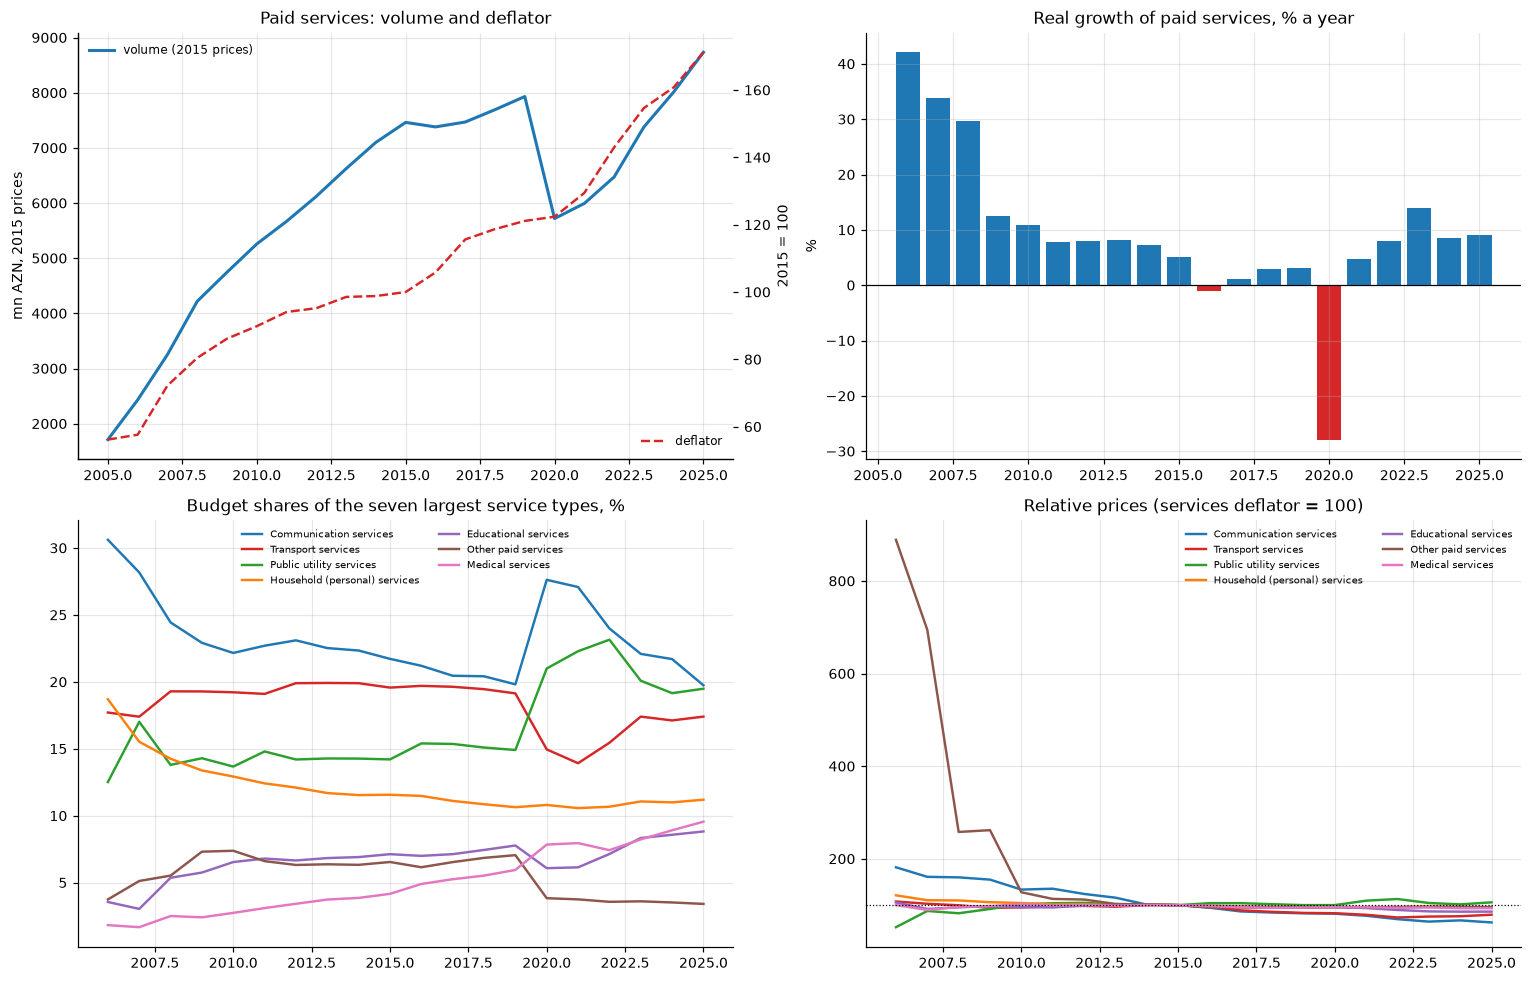

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
a = ax[0, 0]
a.plot(Q_TOT.loc[1995:].index, Q_TOT.loc[1995:], color=PAL[0], lw=2, label=f'volume ({BASE_YR} prices)')
a2 = a.twinx()
a2.plot(P_TOT.loc[1995:].index, P_TOT.loc[1995:], color=PAL[1], lw=1.6, ls='--', label='deflator')
a2.grid(False)
a.set_title('Paid services: volume and deflator'); a.set_ylabel('mn AZN, 2015 prices')
a2.set_ylabel('2015 = 100')
a.legend(loc='upper left', fontsize=8); a2.legend(loc='lower right', fontsize=8)

a = ax[0, 1]
a.bar(PS_Q.index, PS_Q.total - 100, color=[PAL[1] if v < 100 else PAL[0] for v in PS_Q.total])
a.axhline(0, color='k', lw=0.8)
a.set_title('Real growth of paid services, % a year'); a.set_ylabel('%')

a = ax[1, 0]
big = W_SH.loc[EST0:].mean().sort_values(ascending=False).index[:7]
for i, k in enumerate(big):
    a.plot(W_SH.loc[EST0:].index, W_SH.loc[EST0:, k] * 100, color=PAL[i], lw=1.6, label=TLABEL[k])
a.set_title('Budget shares of the seven largest service types, %'); a.legend(fontsize=6.5, ncol=2)

a = ax[1, 1]
for i, k in enumerate(big):
    rel = (P_TYPE[k] / P_TOT * 100).loc[EST0:]
    a.plot(rel.index, rel, color=PAL[i], lw=1.6, label=TLABEL[k])
a.axhline(100, color='k', lw=0.8, ls=':')
a.set_title('Relative prices (services deflator = 100)'); a.legend(fontsize=6.5, ncol=2)
plt.tight_layout(); plt.show()

## Part 8 — Econometric toolkit

`linearmodels` is unavailable here, so the estimators are implemented directly. The three cells below
are the **same code used in FR1, FR3 and FR4**, carried over unchanged so that all four deliverables
share one estimator and one covariance convention. The last cell validates them against `statsmodels`
on simulated data; coefficients, standard errors and test statistics must agree to 1e-8 or the notebook
stops.

Provided: OLS with HC1 and Newey–West HAC covariance; two-stage least squares with first-stage F and
Sargan test; dynamic OLS for cointegrating relations; Wald tests of linear restrictions; variance
inflation factors; seemingly-unrelated regressions with cross-equation restrictions; three-stage least
squares; two-way panel fixed effects with Driscoll–Kraay standard errors; and a damped Gauss–Seidel
solver.

In [14]:
class Fit:
    def __init__(self, **kw): self.__dict__.update(kw)
    def table(self, digits=4):
        t = pd.DataFrame({'coef': self.beta, 'se': self.se, 't': self.tstat, 'p': self.pval},
                         index=self.names)
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in self.pval]
        return t.round(digits)
    def summary(self, title=''):
        out = [f"{title or self.kind}   n={self.n}  R2={self.r2:.4f}  adj={self.r2a:.4f}"]
        if getattr(self, 'extra', None): out.append("  " + self.extra)
        out.append(self.table().to_string())
        return "\n".join(out)
    def __repr__(self): return self.summary()

def _prep(y, X, add_const=True):
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    yv = d['__y__'].to_numpy(float); Xv = d.drop(columns='__y__').to_numpy(float)
    names = [c for c in d.columns if c != '__y__']
    if add_const:
        Xv = np.column_stack([np.ones(len(Xv)), Xv]); names = ['const'] + names
    return yv, Xv, names, d.index

def hac_cov(X, u, XtXi, lags=None):
    '''Newey-West HAC covariance. This corrects INFERENCE for residual dependence;
    it adds no autoregressive term to the model and never changes a fitted value.'''
    n = len(X)
    if lags is None: lags = max(1, int(np.floor(4*(n/100)**(2/9))))
    Xu = X * u[:, None]
    S = Xu.T @ Xu
    for L in range(1, lags+1):
        G = Xu[L:].T @ Xu[:-L]
        S += (1 - L/(lags+1)) * (G + G.T)
    return XtXi @ S @ XtXi

def ols(y, X, cov='hac', lags=None, add_const=True):
    yv, Xv, names, idx = _prep(y, X, add_const)
    n, k = Xv.shape
    XtXi = np.linalg.pinv(Xv.T @ Xv)
    b = XtXi @ Xv.T @ yv
    u = yv - Xv @ b
    dof = max(n-k, 1)
    if   cov == 'hac': V = hac_cov(Xv, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Xv*u[:,None]).T @ (Xv*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    tss = ((yv-yv.mean())**2).sum() if add_const else (yv**2).sum()
    r2 = 1 - (u@u)/tss
    return Fit(kind=f'OLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, X=Xv, y=yv, index=idx,
               resid=pd.Series(u, index=idx), fitted=pd.Series(Xv@b, index=idx), sigma2=(u@u)/dof,
               dof=dof)

def tsls(y, X_endog, X_exog, Z, cov='hac', lags=None):
    '''2SLS for a structural equation. X_endog: jointly determined regressors;
    X_exog: included exogenous; Z: EXCLUDED instruments.
    Reports first-stage F (weak-instrument screen) and Sargan J (over-identification).'''
    En = list(X_endog.columns)
    Xn = [] if X_exog is None or X_exog.shape[1]==0 else list(X_exog.columns)
    Zn = list(Z.columns)
    parts = [p for p in (X_endog, X_exog, Z) if p is not None and p.shape[1] > 0]
    d = pd.concat([y.rename('__y__')] + parts, axis=1).dropna()
    yv = d['__y__'].to_numpy(float)
    E  = d[En].to_numpy(float)
    Xx = d[Xn].to_numpy(float) if Xn else np.empty((len(d), 0))
    Zz = d[Zn].to_numpy(float)
    one = np.ones((len(d), 1))
    W = np.column_stack([one, E, Xx])          # regressors
    I = np.column_stack([one, Xx, Zz])         # instrument set
    names = ['const'] + En + Xn
    n, k = W.shape
    if I.shape[1] < k:
        raise ValueError(f"under-identified: {I.shape[1]} instruments for {k} parameters")
    PiI = np.linalg.pinv(I.T @ I)
    Wh = I @ (PiI @ (I.T @ W))
    b = np.linalg.pinv(Wh.T @ W) @ (Wh.T @ yv)
    u = yv - W @ b
    dof = max(n-k, 1)
    XtXi = np.linalg.pinv(Wh.T @ Wh)
    if   cov == 'hac': V = hac_cov(Wh, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Wh*u[:,None]).T @ (Wh*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    X0 = np.column_stack([one, Xx]); q = Zz.shape[1]
    fsF = {}
    for j, nm in enumerate(En):
        ru = E[:,j] - I @ (PiI @ (I.T @ E[:,j]))
        rr = E[:,j] - X0 @ (np.linalg.pinv(X0.T@X0) @ (X0.T @ E[:,j]))
        den = (ru@ru)/max(n-I.shape[1], 1)
        fsF[nm] = ((rr@rr - ru@ru)/q)/den if den > 0 else np.nan
    over = I.shape[1] - k
    if over > 0:
        uh = I @ (PiI @ (I.T @ u)); J = n*(uh@uh)/(u@u); Jp = 1-stats.chi2.cdf(J, over)
    else:
        J, Jp = np.nan, np.nan
    r2 = 1 - (u@u)/((yv-yv.mean())**2).sum()
    extra = ("first-stage F: " + ", ".join(f"{m}={v:.1f}" for m, v in fsF.items()) +
             (f" | Sargan J({over})={J:.2f} p={Jp:.3f}" if over > 0 else " | just-identified"))
    return Fit(kind=f'2SLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, index=d.index,
               resid=pd.Series(u, index=d.index), fitted=pd.Series(W@b, index=d.index),
               first_stage_F=fsF, J=J, J_p=Jp, extra=extra, sigma2=(u@u)/dof, dof=dof)

def dols(y, X, leads=1, lags_=1, cov='hac'):
    '''Stock-Watson Dynamic OLS of a cointegrating relation.
    The levels regression is augmented with LEADS AND LAGS OF THE DIFFERENCES OF THE
    REGRESSORS to purge endogeneity and residual serial correlation.
    The dependent variable's own lags NEVER enter: this is not an autoregression.'''
    aug = {}
    for c in X.columns:
        dx = X[c].diff()
        for L in range(-leads, lags_+1):
            if L == 0: continue
            aug[f'd_{c}_{"F" if L<0 else "L"}{abs(L)}'] = dx.shift(L)
    Xa = pd.concat([X, pd.DataFrame(aug, index=X.index)], axis=1)
    f = ols(y, Xa, cov=cov)
    f.kind = f'DOLS[leads={leads},lags={lags_}]'
    f.long_run    = pd.Series(f.beta[1:1+X.shape[1]], index=list(X.columns))
    f.long_run_se = pd.Series(f.se[1:1+X.shape[1]],   index=list(X.columns))
    f.core = list(X.columns)
    return f

def wald_test(fit, R, q):
    '''Test R*beta = q. R is (m,k) over the fit's parameter vector.'''
    R = np.atleast_2d(np.asarray(R, float)); q = np.atleast_1d(np.asarray(q, float))
    d = R @ fit.beta - q
    Vr = R @ fit.V @ R.T
    W = float(d @ np.linalg.pinv(Vr) @ d)
    return W, 1 - stats.chi2.cdf(W, R.shape[0])

def restrict_row(fit, name, value=1.0):
    R = np.zeros(len(fit.beta)); R[fit.names.index(name)] = 1.0
    return wald_test(fit, R, [value])

def vif(X):
    Xd = X.dropna()
    out = {}
    for c in Xd.columns:
        rest = Xd.drop(columns=c)
        if rest.shape[1] == 0: out[c] = 1.0; continue
        r2 = ols(Xd[c], rest, cov='nonrobust').r2
        out[c] = np.inf if r2 >= 1 else 1/(1-r2)
    return pd.Series(out)
print("estimators defined: ols, tsls, dols, wald_test, vif")

estimators defined: ols, tsls, dols, wald_test, vif


In [15]:
def sur(eqs, restrictions=None, iterate=3):
    '''Seemingly-unrelated regressions by feasible GLS.
    `restrictions` = (R, q) imposes R*beta = q exactly (used for adding-up in share systems).'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Y = [eqs[nm][0].loc[idx].to_numpy(float) for nm in names]
    Xs = [np.column_stack([np.ones(len(idx)), eqs[nm][1].loc[idx].to_numpy(float)]) for nm in names]
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y); Xb = np.zeros((n*m, sum(ks))); c = 0
    for i, x in enumerate(Xs):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = x; c += ks[i]
    b = np.linalg.pinv(Xb.T@Xb) @ Xb.T @ yb
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        Amat = Xb.T @ Om @ Xb; rhs = Xb.T @ Om @ yb
        if restrictions is not None:
            Rm, qv = restrictions
            KKT = np.block([[Amat, Rm.T], [Rm, np.zeros((Rm.shape[0], Rm.shape[0]))]])
            b = (np.linalg.pinv(KKT) @ np.concatenate([rhs, qv]))[:Amat.shape[0]]
        else:
            b = np.linalg.pinv(Amat) @ rhs
    V = np.linalg.pinv(Xb.T @ Om @ Xb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, c = {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; out[nm] = t; c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(U.T, index=idx, columns=names), U@U.T/n

def system_3sls(eqs, instruments, iterate=2):
    '''Three-stage least squares for a simultaneous structural system.
    Stage 1-2: project all regressors on the instrument set (2SLS).
    Stage 3: re-weight by the cross-equation error covariance for efficiency.'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X, instruments], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Z = np.column_stack([np.ones(len(idx)), instruments.loc[idx].to_numpy(float)])
    Pz = Z @ np.linalg.pinv(Z.T@Z) @ Z.T
    Y, Xs, Xh = [], [], []
    for nm in names:
        y, X = eqs[nm]
        Xv = np.column_stack([np.ones(len(idx)), X.loc[idx].to_numpy(float)])
        Y.append(y.loc[idx].to_numpy(float)); Xs.append(Xv); Xh.append(Pz @ Xv)
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y)
    Xb = np.zeros((n*m, sum(ks))); Hb = np.zeros((n*m, sum(ks))); c = 0
    for i in range(m):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = Xs[i]; Hb[i*n:(i+1)*n, c:c+ks[i]] = Xh[i]; c += ks[i]
    b = np.linalg.pinv(Hb.T@Xb) @ (Hb.T@yb)
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        b = np.linalg.pinv(Hb.T @ Om @ Hb) @ (Hb.T @ Om @ yb)
    V = np.linalg.pinv(Hb.T @ Om @ Hb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, res, c = {}, {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; t['p'] = 2*(1-stats.norm.cdf(t.t.abs()))
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in t.p]
        out[nm] = t
        res[nm] = pd.Series(Y[i] - Xs[i]@b[c:c+ks[i]], index=idx); c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(res), U@U.T/n, idx

def panel_fe(df, dep, regs, entity='unit', time='year', twoway=True, dk_lags=2):
    '''Two-way (entity and time) fixed-effects within estimator with Driscoll-Kraay
    standard errors, robust to cross-sectional dependence and limited time dependence.'''
    d = df[[entity, time, dep] + regs].dropna().copy()
    cols = [dep] + regs
    if twoway:
        for c in cols:
            d[c] = (d[c] - d.groupby(entity)[c].transform('mean')
                         - d.groupby(time)[c].transform('mean') + d[c].mean())
    else:
        for c in cols:
            d[c] = d[c] - d.groupby(entity)[c].transform('mean')
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    XtXi = np.linalg.pinv(Xv.T@Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv@b
    nN, nT = d[entity].nunique(), d[time].nunique()
    k = len(regs) + nN + (nT-1 if twoway else 0)
    ht = (pd.DataFrame(Xv*u[:,None], index=d[time].to_numpy())
            .groupby(level=0).sum().sort_index().to_numpy())
    S = ht.T @ ht
    for L in range(1, dk_lags+1):
        G = ht[L:].T @ ht[:-L]; S += (1 - L/(dk_lags+1))*(G + G.T)
    V = XtXi @ S @ XtXi * (len(d)/max(len(d)-k, 1))
    se = np.sqrt(np.maximum(np.diag(V), 0)); t = b/se; dof = max(len(d)-k, 1)
    r2 = 1 - (u@u)/(yv@yv)
    return Fit(kind='Panel 2-way FE [Driscoll-Kraay]' if twoway else 'Panel entity FE [DK]',
               beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)), names=regs,
               n=len(d), k=k, r2=r2, r2a=1-(1-r2)*(len(d)-1)/dof, V=V,
               resid=pd.Series(u, index=d.index), nN=nN, nT=nT, dof=dof,
               extra=f"units={nN}  periods={nT}")

def gauss_seidel(eq_funcs, order, state, exog, max_iter=800, tol=1e-9, damp=0.55):
    '''Solve one period of the simultaneous nonlinear system by damped Gauss-Seidel.
    eq_funcs: variable -> f(state, exog) returning that variable's new value.'''
    s = dict(state)
    err = np.inf
    for it in range(max_iter):
        err = 0.0
        for v in order:
            new = eq_funcs[v](s, exog)
            old = s.get(v, new)
            if old is None or not np.isfinite(old): old = new
            upd = damp*new + (1-damp)*old
            err = max(err, abs(upd-old)/max(abs(old), 1e-6))
            s[v] = upd
        if err < tol:
            return s, it+1, err
    return s, max_iter, err
print("estimators defined: sur, system_3sls, panel_fe, gauss_seidel")

estimators defined: sur, system_3sls, panel_fe, gauss_seidel


In [16]:
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

rng = np.random.default_rng(SEED); n = 80
Xt = pd.DataFrame(rng.standard_normal((n,3)), columns=['a','b','c'])
yt = pd.Series(1 + 2*Xt.a - 1.5*Xt.b + .5*Xt.c + rng.standard_normal(n)*.3, name='y')
rows = []
f0 = ols(yt, Xt, cov='nonrobust'); r0 = sm.OLS(yt, sm.add_constant(Xt)).fit()
rows.append(['OLS coefficients', np.abs(f0.beta-r0.params.values).max()])
rows.append(['OLS standard errors', np.abs(f0.se-r0.bse.values).max()])
f1 = ols(yt, Xt, cov='hc1'); r1 = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HC1')
rows.append(['HC1 robust SE', np.abs(f1.se-r1.bse.values).max()])
f2 = ols(yt, Xt, cov='hac', lags=3)
r2_ = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HAC',
        cov_kwds={'maxlags':3, 'use_correction':False})
rows.append(['Newey-West HAC SE', np.abs(f2.se-r2_.bse.values).max()])
Zt = pd.DataFrame(rng.standard_normal((n,2)), columns=['z1','z2'])
en = pd.Series(.8*Zt.z1 + .6*Zt.z2 + rng.standard_normal(n)*.5, name='en')
y2 = pd.Series(1 + 1.5*en + .7*Xt.a + rng.standard_normal(n)*.4, name='y2')
g = tsls(y2, en.to_frame(), Xt[['a']], Zt, cov='nonrobust')
r3 = IV2SLS(y2, sm.add_constant(pd.concat([en, Xt.a], axis=1)),
                sm.add_constant(pd.concat([Xt.a, Zt], axis=1))).fit()
rows.append(['2SLS coefficients', np.abs(g.beta-r3.params.values).max()])
rows.append(['2SLS standard errors', np.abs(g.se-r3.bse.values).max()])
# 3SLS on a just-identified single equation must reproduce 2SLS
o3, _, _, _ = system_3sls({'eq': (y2, pd.concat([en, Xt.a], axis=1))},
                          pd.concat([Xt.a, Zt], axis=1))
rows.append(['3SLS vs 2SLS (just-identified)', np.abs(o3['eq'].coef.values - g.beta).max()])
# panel FE within-transform must reproduce OLS on demeaned data
pdf = pd.DataFrame({'unit': np.repeat(np.arange(10), 8), 'year': np.tile(np.arange(8), 10)})
pdf['x'] = rng.standard_normal(80); pdf['fe'] = pdf.unit*0.3
pdf['y'] = 1 + 0.6*pdf.x + pdf.fe + rng.standard_normal(80)*.2
fp = panel_fe(pdf, 'y', ['x'], twoway=False)
dd = pdf.copy()
for c in ['y','x']: dd[c] = dd[c] - dd.groupby('unit')[c].transform('mean')
rows.append(['panel FE coefficient', abs(fp.beta[0] - ols(dd.y, dd[['x']], cov='nonrobust').beta[1])])
chk = pd.DataFrame(rows, columns=['check','max abs difference'])
chk['verdict'] = np.where(chk['max abs difference'] < 1e-8, 'exact', 'MISMATCH')
display(chk)
assert (chk.verdict == 'exact').all(), "estimator validation failed"
print("all estimators reproduce statsmodels to machine precision")
print(f"\nWald machinery sanity check: H0 slope on 'a' = 2 (true value) -> "
      f"p = {restrict_row(f0, 'a', 2.0)[1]:.3f}  (should not reject)")
print(f"                             H0 slope on 'a' = 0            -> "
      f"p = {restrict_row(f0, 'a', 0.0)[1]:.3f}  (should reject)")

,check,max abs difference,verdict
0,OLS coefficients,0.000,exact
1,OLS standard errors,0.000,exact
2,HC1 robust SE,0.000,exact
3,Newey-West HAC SE,0.000,exact
4,2SLS coefficients,0.000,exact
5,2SLS standard errors,0.000,exact
6,3SLS vs 2SLS (just-identified),0.000,exact
7,panel FE coefficient,0.000,exact


all estimators reproduce statsmodels to machine precision

Wald machinery sanity check: H0 slope on 'a' = 2 (true value) -> p = 0.383  (should not reject)
                             H0 slope on 'a' = 0            -> p = 0.000  (should reject)


## Part 9 — What is estimated, what is forbidden, and what was rejected

### 9.1 The no-autoregression constraint, stated precisely

No equation in FR5 contains a lagged dependent variable, a moving-average error, or a conditional
variance process. Three lag constructs appear, and each is an accounting or inference device:

| Construct | Where | Why it is not an autoregression |
|---|---|---|
| Newey–West HAC covariance | every time-series equation | Affects **standard errors only**; point estimates are OLS |
| Chained volume indices | Part 5 | The official chain-linking identity $Q_t = Q_{t-1}\cdot I_t$, an accounting relation between a published level and a published index, not a fitted equation |
| DOLS leads/lags of **regressor** differences | Part 10 robustness | Standard endogeneity correction in a cointegrating regression; the dependent variable's own lags never enter |

Two **dummy variables** for 2020 and 2021 also appear. A dummy is not a lag: it identifies a named
historical event — the pandemic — rather than propagating the dependent variable. Fact 2 in Part 7 shows
why omitting them would corrupt the income elasticity, and Part 16 sets them to zero over the forecast.

### 9.2 Identification devices

(1) restrictions tested and then imposed; (2) adding-up obtained **by construction** rather than by
estimation — the central advantage of writing the model as a demand system; (3) parsimony; (4) selection
by out-of-sample forecast accuracy rather than by fit, with a window held back entirely.

### 9.3 Specifications tested and rejected

Produced by running each candidate. Every number below is computed in this notebook.

In [17]:
# ---------- shared objects for Parts 9-11 --------------------------------------------------------
def L(x): return np.log(x)
C20 = pd.Series({y: (1.0 if y == 2020 else 0.0) for y in F.index}, name='c20')
C21 = pd.Series({y: (1.0 if y == 2021 else 0.0) for y in F.index}, name='c21')
RELP_TOT = L(P_TOT / (cpi * 100))               # price of services relative to the general price level
YDPC     = L(yd / pop)                          # real household disposable income per head
# FR1's rserv_hh is the same volume series (Part 5.1 verified agreement to 0.0005%) but starts in
# 1990 rather than 2005, because FR1 chained it from the workbook's own growth index. Tier 1 uses the
# longer series to gain five observations on the key parameter; the two are interchangeable.
Q_LONG   = F['rserv_hh'].combine_first(Q_TOT)
_ov = [y for y in Q_TOT.dropna().index if y in F.rserv_hh.dropna().index]
assert float((Q_TOT.loc[_ov] / F.rserv_hh.loc[_ov] - 1).abs().max()) < 5e-4, \
    'the FR5 chained volume and FR1 rserv_hh are not the same series'
QPC      = L(Q_LONG / pop)                     # real volume of paid services per head
RELP     = {k: L(P_TYPE[k] / P_TOT) for k in TKEYS}   # own price relative to the services deflator

def ts(dep, xd, cov='hac', lags=2):
    d = pd.concat([dep.rename('_y')] + [v.rename(k) for k, v in xd.items()], axis=1).dropna()
    return ols(d['_y'], d.drop(columns='_y'), cov=cov, lags=lags), d

REJ = []
def reject(spec, block, verdict, evidence):
    REJ.append(dict(specification=spec, block=block, verdict=verdict, evidence=evidence))
print('shared objects defined;  paid-services volume per head and real income per head:')
display(pd.DataFrame({'volume per head (AZN, 2015 prices)': np.exp(QPC) * 1000,
                      'real income per head': np.exp(YDPC),
                      'relative price of services': np.exp(RELP_TOT)}
                     ).loc[[2000, 2010, 2019, 2020, LAST_ACT]].round(3))

shared objects defined;  paid-services volume per head and real income per head:


,"volume per head (AZN, 2015 prices)",real income per head,relative price of services
2000,115.988,1.128,NaN
2010,588.534,3.084,1.058
2019,798.675,3.919,0.903
2020,571.886,3.654,0.886
2025,852.700,3.987,0.875


In [18]:
# ---- R1  the naive time-series alternative: volume on its own trend ----------------------------
trend = pd.Series(F.index - 2000., index=F.index, name='trend')
f_tr, _ = ts(QPC, {'trend': trend})
f_yd, _ = ts(QPC, {'ln_income_pc': YDPC})
print('R1 — is a trend enough? volume per head on a trend alone versus on income')
print(f'    trend only : coefficient {f_tr.beta[1]:+.4f} (t = {f_tr.tstat[1]:+.1f}), R2 = {f_tr.r2:.3f}')
print(f'    income     : elasticity  {f_yd.beta[1]:+.4f} (t = {f_yd.tstat[1]:+.1f}), R2 = {f_yd.r2:.3f}')
print('    Both fit, because both regressors trend. The discriminating test is Part 10.2, which')
print('    shows the income specification forecasts and the trend does not, and the trend carries no')
print('    structural interpretation and cannot respond to a scenario. REJECTED as a structure.')
reject('volume per head on a deterministic trend', 'aggregate demand', 'REJECTED - not structural',
       f'fits (R2 = {f_tr.r2:.3f}) but has no economic content and cannot respond to a scenario')

# ---- R2  omitting the pandemic ------------------------------------------------------------------
a1, _ = ts(QPC, {'ln_income_pc': YDPC, 'c20': C20, 'c21': C21})
a0, _ = ts(QPC, {'ln_income_pc': YDPC})
print(f'\nR2 — what omitting the pandemic dummies does to the income elasticity')
print(f'    with 2020 and 2021 dummies : {a1.beta[1]:+.3f} (t = {a1.tstat[1]:+.1f}), R2 = {a1.r2:.3f}')
print(f'    without                    : {a0.beta[1]:+.3f} (t = {a0.tstat[1]:+.1f}), R2 = {a0.r2:.3f}')
print(f'    dummies: 2020 = {a1.beta[2]:+.3f} (t = {a1.tstat[2]:+.1f}), 2021 = {a1.beta[3]:+.3f} (t = {a1.tstat[3]:+.1f}) - both significant.')
print('    Omitting them loads a lockdown onto the income elasticity. RETAINED, and set to zero')
print('    over the forecast, where no such event is assumed.')

# ---- R3  the relative price in the aggregate equation ------------------------------------------
rows = []
for nm, xd in [('income only', {'ln_income_pc': YDPC, 'c20': C20, 'c21': C21}),
               ('income + relative price', {'ln_income_pc': YDPC, 'ln_relprice': RELP_TOT,
                                            'c20': C20, 'c21': C21}),
               ('income deflated by the service price (homogeneity imposed)',
                {'ln_income_srv': L(yd / pop / np.exp(RELP_TOT)), 'c20': C20, 'c21': C21}),
               ('non-oil GDP per head instead of income',
                {'ln_gdp_pc': L(F.rgdpnon / pop), 'ln_relprice': RELP_TOT, 'c20': C20, 'c21': C21})]:
    f, d = ts(QPC, xd)
    has_p = 'ln_relprice' in xd
    ip = list(xd).index('ln_relprice') + 1 if has_p else None
    rows.append(dict(specification=nm, n=f.n, R2=round(f.r2, 3),
                     income_or_gdp_coef=round(f.beta[1], 3), t=round(f.tstat[1], 1),
                     price_coef=(round(f.beta[ip], 3) if has_p else np.nan),
                     price_t=(round(f.tstat[ip], 1) if has_p else np.nan)))
print('\nR3 — candidate aggregate specifications, in-sample')
display(pd.DataFrame(rows).set_index('specification'))
_t = pd.DataFrame(rows).set_index('specification')
_p1 = float(_t.loc['income + relative price', 'price_coef'])
_p2 = float(_t.loc['non-oil GDP per head instead of income', 'price_coef'])
print(f'    With household income the price term is {_p1:+.3f} - correctly signed, but '
      f'insignificant (t = {float(_t.loc["income + relative price","price_t"]):+.1f}).')
print(f'    Substituting non-oil GDP for household income turns it {_p2:+.3f}, which is the wrong')
print('    sign for a demand curve: the equation is then no longer a demand relation at all.')
print('    Household income is the correct regressor, and Part 10.2 settles the price question')
print('    out of sample.')
reject('non-oil GDP per head in place of household income', 'aggregate demand',
       'REJECTED - wrong-signed price term',
       f'price coefficient {_p2:+.3f} when GDP replaces household income')

R1 — is a trend enough? volume per head on a trend alone versus on income
    trend only : coefficient +0.0871 (t = +8.8), R2 = 0.840
    income     : elasticity  +1.5431 (t = +35.0), R2 = 0.984
    Both fit, because both regressors trend. The discriminating test is Part 10.2, which
    shows the income specification forecasts and the trend does not, and the trend carries no
    structural interpretation and cannot respond to a scenario. REJECTED as a structure.

R2 — what omitting the pandemic dummies does to the income elasticity
    with 2020 and 2021 dummies : +1.561 (t = +36.6), R2 = 0.988
    without                    : +1.543 (t = +35.0), R2 = 0.984
    dummies: 2020 = -0.221 (t = -9.5), 2021 = -0.096 (t = -4.3) - both significant.
    Omitting them loads a lockdown onto the income elasticity. RETAINED, and set to zero
    over the forecast, where no such event is assumed.

R3 — candidate aggregate specifications, in-sample


,n,R2,income_or_gdp_coef,t,price_coef,price_t
specification,,,,,,
income only,26,0.988,1.561,36.600,NaN,NaN
income + relative price,21,0.975,1.362,16.800,-0.174,-0.700
income deflated by the service price (homogeneity imposed),21,0.940,1.127,11.400,NaN,NaN
non-oil GDP per head instead of income,21,0.878,1.697,7.200,1.536,2.200


    With household income the price term is -0.174 - correctly signed, but insignificant (t = -0.7).
    Substituting non-oil GDP for household income turns it +1.536, which is the wrong
    sign for a demand curve: the equation is then no longer a demand relation at all.
    Household income is the correct regressor, and Part 10.2 settles the price question
    out of sample.


## Part 10 — Tier 1: aggregate demand for paid services

### 10.1 The specification

$$\ln\!\left(\frac{Q_t}{N_t}\right) \;=\; \alpha \;+\; \eta \ln\!\left(\frac{Y^d_t}{N_t}\right) \;+\; \varepsilon \ln\!\left(\frac{P^s_t}{P_t}\right) \;+\; \delta_{20} D^{2020}_t + \delta_{21} D^{2021}_t + u_t$$

$Q$ is the real volume of paid services, $N$ population, $Y^d$ real household disposable income, and
$P^s/P$ the relative price of services — **observed**, by the identity of Part 5. $\eta$ is the income
elasticity of demand for services and $\varepsilon$ the own-price elasticity. Theory expects
$\eta > 1$ for services in a middle-income economy and $\varepsilon < 0$.

### 10.2 Choosing the specification out of sample

Each candidate is estimated up to a cut-off and then used to predict the volume per head over the
following years from actual drivers. Three cut-offs are pooled. Selection is on forecast error, not fit.

In [19]:
def oos_agg(xkeys, cuts=(2015, 2017, 2019), end=LAST_ACT):
    XA = pd.DataFrame({'ln_income_pc': YDPC, 'ln_relprice': RELP_TOT,
                       'ln_income_srv': L(yd / pop / np.exp(RELP_TOT)),
                       'trend': trend, 'c20': C20, 'c21': C21})
    d = pd.concat([QPC.rename('_y'), XA], axis=1).dropna()
    errs = []
    for CUT in cuts:
        est, hold = d[d.index <= CUT], d[(d.index > CUT) & (d.index <= end)]
        if not len(hold): continue
        Xm = np.column_stack([np.ones(len(est))] + [est[c].values for c in xkeys])
        b = np.linalg.lstsq(Xm, est['_y'].values, rcond=None)[0]
        pr = b[0] + sum(b[i+1] * hold[c] for i, c in enumerate(xkeys))
        errs.append(((np.exp(pr) / np.exp(hold['_y']) - 1) * 100).values)
    e = np.concatenate(errs)
    return float(np.sqrt(np.mean(e ** 2))), float(np.median(np.abs(e))), len(e)

CANDS = {'income only':                    ['ln_income_pc', 'c20', 'c21'],
         'income + relative price':        ['ln_income_pc', 'ln_relprice', 'c20', 'c21'],
         'income deflated by service price': ['ln_income_srv', 'c20', 'c21'],
         'trend only':                     ['trend', 'c20', 'c21'],
         'income + trend':                 ['ln_income_pc', 'trend', 'c20', 'c21']}
rows = []
for nm, ks in CANDS.items():
    r, m, n = oos_agg(ks)
    rows.append(dict(specification=nm, n_predictions=n, RMSE_pct=round(r, 2), median_abs_pct=round(m, 2)))
SEL_A = pd.DataFrame(rows).sort_values('RMSE_pct').set_index('specification')
display(SEL_A)
BEST_A = SEL_A.index[0]
print(f'WINNER: {BEST_A}')
print()
print('Two things are worth stating plainly.')
print(f' 1. The relative price makes the forecast WORSE ({SEL_A.loc["income + relative price","RMSE_pct"]:.1f}% against '
      f'{SEL_A.loc["income only","RMSE_pct"]:.1f}%), even though it is')
print('    correctly signed. Over this sample the relative price of services rose almost')
print('    monotonically while volume grew strongly, so the price coefficient is fitted to a')
print('    near-collinear regressor and does not travel. It is therefore NOT used in the')
print('    forecasting equation - but Part 17 exposes it as a scenario lever, so a tariff change')
print('    can still be analysed with the elasticity the data do support.')
print(f' 2. The trend-only specification, which fitted well in R1, scores {SEL_A.loc["trend only","RMSE_pct"]:.1f}% - among the')
print('    worst. Fit and forecasting value are different things.')
reject('relative price in the aggregate demand equation', 'aggregate demand',
       'REJECTED - fails out of sample',
       f'pooled OOS RMSE {SEL_A.loc["income + relative price","RMSE_pct"]:.2f}% vs '
       f'{SEL_A.loc["income only","RMSE_pct"]:.2f}% for income alone')
reject('trend in the aggregate demand equation', 'aggregate demand',
       'REJECTED - fails out of sample', f'pooled OOS RMSE {SEL_A.loc["trend only","RMSE_pct"]:.2f}%')

,n_predictions,RMSE_pct,median_abs_pct
specification,,,
income only,24,10.140,6.650
income + relative price,24,13.640,7.920
income + trend,24,20.180,16.970
income deflated by service price,24,25.200,19.990
trend only,24,148.930,114.360


WINNER: income only

Two things are worth stating plainly.
 1. The relative price makes the forecast WORSE (13.6% against 10.1%), even though it is
    correctly signed. Over this sample the relative price of services rose almost
    monotonically while volume grew strongly, so the price coefficient is fitted to a
    near-collinear regressor and does not travel. It is therefore NOT used in the
    forecasting equation - but Part 17 exposes it as a scenario lever, so a tariff change
    can still be analysed with the elasticity the data do support.
 2. The trend-only specification, which fitted well in R1, scores 148.9% - among the
    worst. Fit and forecasting value are different things.


In [20]:
print('E1 — the estimated aggregate demand equation for paid services')
EQ_A, dA = ts(QPC, {'ln_income_pc': YDPC, 'c20': C20, 'c21': C21})
display(EQ_A.table())
ETA = float(EQ_A.beta[1])
print(f'    income elasticity  eta = {ETA:.3f}  (t = {EQ_A.tstat[1]:.1f}),  n = {EQ_A.n} '
      f'({int(dA.index.min())}-{int(dA.index.max())}),  R2 = {EQ_A.r2:.3f}')
print()
w_stat, w_p = restrict_row(EQ_A, 'ln_income_pc', 1.0)
print(f'    Wald test of H0: eta = 1 (services neither luxury nor necessity):')
print(f'      chi2 = {w_stat:.2f}, p = {w_p:.4f}  ->  {"REJECTED" if w_p < 0.05 else "not rejected"}')
print(f'    Paid services are a LUXURY in the Engel sense: a 1% rise in real income per head raises')
print(f'    the volume demanded per head by {ETA:.2f}%. That single number is the core structural')
print('    parameter of this deliverable, and it is what makes the services market grow faster than')
print('    the economy as a whole.')
print()
dd = pd.DataFrame({'dq': QPC.diff(), 'dy': YDPC.diff(), 'c20': C20, 'c21': C21}).dropna()
f_d = ols(dd.dq, dd[['dy', 'c20', 'c21']], cov='hac', lags=1)
print(f'    Robustness in growth form: elasticity {f_d.beta[1]:+.3f} (t = {f_d.tstat[1]:+.1f}), R2 = {f_d.r2:.3f}.')
print(f'    The difference estimate {f_d.beta[1]:.2f} is {abs(f_d.beta[1]/ETA-1)*100:.0f}% below the level estimate {ETA:.2f}. They are')
print('    the same sign and the same order of magnitude, and both are precisely estimated, but they')
print('    are not equal, and the gap should be read for what it is: the level coefficient is a')
print('    LONG-RUN elasticity and the difference coefficient an impact elasticity, with households')
print('    adjusting service consumption over more than one year. Part 18 lists the consequence -')
print('    because no lagged dependent variable is permitted, the speed of that adjustment is not')
print('    estimated, so the first forecast year will overstate how fast demand responds.')
print()
print('    Price elasticity, reported although not used in the forecast:')
f_p, _ = ts(QPC, {'ln_income_pc': YDPC, 'ln_relprice': RELP_TOT, 'c20': C20, 'c21': C21})
EPS_REPORTED = float(f_p.beta[2])
print(f'      eta = {f_p.beta[1]:+.3f} (t = {f_p.tstat[1]:+.1f}),  epsilon = {EPS_REPORTED:+.3f} (t = {f_p.tstat[2]:+.1f})')
print(f'      correctly signed, not significant; used in Part 17 as the price lever.')
AUD = [dict(equation='E1 aggregate volume of paid services', n=EQ_A.n, R2=round(EQ_A.r2, 4),
            specification='ln(Q/N) on ln(Yd/N) + 2020 and 2021 dummies',
            note=f'income elasticity {ETA:.3f}; price term tested and rejected out of sample')]

E1 — the estimated aggregate demand equation for paid services


,coef,se,t,p,sig
const,-2.360,0.052,-45.397,0.000,***
ln_income_pc,1.561,0.043,36.550,0.000,***
c20,-0.221,0.023,-9.494,0.000,***
c21,-0.096,0.023,-4.263,0.000,***


    income elasticity  eta = 1.561  (t = 36.6),  n = 26 (2000-2025),  R2 = 0.988

    Wald test of H0: eta = 1 (services neither luxury nor necessity):
      chi2 = 172.37, p = 0.0000  ->  REJECTED
    Paid services are a LUXURY in the Engel sense: a 1% rise in real income per head raises
    the volume demanded per head by 1.56%. That single number is the core structural
    parameter of this deliverable, and it is what makes the services market grow faster than
    the economy as a whole.

    Robustness in growth form: elasticity +1.183 (t = +5.4), R2 = 0.801.
    The difference estimate 1.18 is 24% below the level estimate 1.56. They are
    the same sign and the same order of magnitude, and both are precisely estimated, but they
    are not equal, and the gap should be read for what it is: the level coefficient is a
    LONG-RUN elasticity and the difference coefficient an impact elasticity, with households
    adjusting service consumption over more than one year. Part 18 lists t

## Part 11 — Tier 2: the thirteen-type demand system

### 11.1 Form

The budget shares of the thirteen service types are modelled as a **linear-approximate almost-ideal
demand system (LA-AIDS)**, written in log-odds against a reference type so that predicted shares are
positive by construction:

$$\ln\!\left(\frac{w_{i,t}}{w_{r,t}}\right) \;=\; \alpha_i \;+\; \beta_i \ln\!\left(\frac{X_t}{N_t P^s_t}\right) \;+\; \gamma_i \ln\!\left(\frac{p_{i,t}}{p_{r,t}}\right) \;+\; u_{i,t}$$

and shares are recovered by $w_i = \exp(z_i)/\sum_j \exp(z_j)$, which makes them sum to **one exactly**.
Transport is the reference type, being the second largest and the most stable.

Three properties make this the right object for the task:

1. **Adding-up is structural, not estimated.** The softmax guarantees $\sum_i w_i = 1$ in every year of
   the forecast, so the thirteen types always reproduce the total. Nothing is normalised after the fact
   and there is no residual category absorbing the error.
2. **$\beta_i$ is the Engel slope**, so $1 + \beta_i/w_i$ is the **expenditure elasticity** of service
   $i$. These elasticities are the direct answer to which services grow as households get richer.
3. **$\gamma_i$ is the relative-price response**, identified here because relative prices within
   services diverged very widely (Part 7, Fact 4) — unlike the aggregate equation, where the single
   relative price is too collinear with income to identify anything.

### 11.2 Selection with a window held back

Three candidates per system — constant shares, Engel only, and Engel plus relative price — are compared
out of sample. Five hold-out windows are used, **four for choosing and the fifth withheld entirely**, so
the reported validation number is not contaminated by the choice. Errors are measured in **percentage
points of the share**, which is the meaningful unit: a percentage error on a share of 0.4% is
uninformative.

2020 and 2021 are excluded from the error measurement. The pandemic reallocated the budget for reasons
a demand system is not meant to anticipate, and including it would simply reward whichever
specification happened to be closest to a lockdown.

In [21]:
REF = 'transport'
XSRV = L(Q_LONG / pop)                      # real service expenditure per head = the volume per head
LOW  = {k: L(W_SH[k] / W_SH[REF]) for k in TKEYS}
CANDS_S = {'const': [], 'engel': ['x'], 'engel_price': ['x', 'p']}

def _cols(k):
    return {'x': XSRV, 'p': RELP[k] - RELP[REF]}

def fit_system(pick, est_years, anchor=None, restrict=False):
    """Estimate every share equation on est_years and add-factor it to reproduce the anchor year.

    With restrict=True the own-price coefficient is constrained so that the implied own-price
    elasticity of VOLUME cannot be positive. Under the softmax, d ln w_i / d ln p_i = gamma_i (1-w_i),
    so the volume elasticity is gamma_i (1-w_i) - 1 and the law of demand requires
    gamma_i <= 1/(1-w_i). Where the free estimate violates that, gamma is set to the boundary
    (a perfectly price-inelastic volume) and the remaining coefficients are re-estimated given it,
    which is exact constrained least squares for a single binding inequality.
    """
    anchor = max(est_years) if anchor is None else anchor
    wb = W_SH.loc[[y for y in est_years if y in W_SH.index]].mean()
    par = {}
    for k in TKEYS:
        if k == REF:
            par[k] = dict(mode='reference', b={}, const=0.0, addf=0.0, fit=None, bound=False); continue
        xs = CANDS_S[pick[k]]
        if not xs:
            par[k] = dict(mode='const', b={}, const=float(LOW[k].loc[anchor]), addf=0.0,
                          fit=None, bound=False)
            continue
        cols = {n: _cols(k)[n] for n in xs}
        d = pd.concat([LOW[k].rename('_y')] + [v.rename(n) for n, v in cols.items()],
                      axis=1).reindex(est_years).dropna()
        f = ols(d['_y'], d.drop(columns='_y'), cov='hac', lags=2)
        b = {n: float(f.beta[f.names.index(n)]) for n in xs}
        const = float(f.beta[0]); bound = False
        if restrict and 'p' in b:
            gmax = 1.0 / (1.0 - float(wb[k]))
            if b['p'] > gmax:
                bound = True
                b['p'] = gmax
                y2 = d['_y'] - gmax * d['p']
                f2 = ols(y2, d[[c for c in xs if c != 'p']], cov='hac', lags=2)
                const = float(f2.beta[0])
                for n in [c for c in xs if c != 'p']:
                    b[n] = float(f2.beta[f2.names.index(n)])
        lp = const + sum(b[n] * cols[n].loc[anchor] for n in xs)
        par[k] = dict(mode=pick[k], b=b, const=const,
                      addf=float(LOW[k].loc[anchor] - lp), fit=f, bound=bound)
    return par

def predict_shares(par, years):
    z = {}
    for k in TKEYS:
        p = par[k]
        if p['mode'] in ('reference',):
            z[k] = pd.Series(0.0, index=years); continue
        if p['mode'] == 'const':
            z[k] = pd.Series(p['const'], index=years); continue
        cols = _cols(k)
        z[k] = pd.Series([p['const'] + p['addf']
                          + sum(p['b'][n] * cols[n].loc[y] for n in p['b']) for y in years],
                         index=years)
    e = np.exp(pd.DataFrame(z, index=years)[TKEYS])
    return e.div(e.sum(axis=1), axis=0)

RESTRICT = False        # switched on in Part 11.4 once the restriction has been tested
SELW = [(2011, 2019), (2013, 2019), (2015, LAST_ACT), (2017, LAST_ACT)]   # used to CHOOSE
VALW = [(2019, LAST_ACT)]                                                  # withheld entirely
EXCL = (2020, 2021)

def score(pick, wins, y0=None):
    y0 = EST0 if y0 is None else y0
    out = []
    for CUT, END in wins:
        est = [y for y in W_SH.index if y0 <= y <= CUT]
        fy  = [y for y in W_SH.index if CUT < y <= END and y not in EXCL]
        if not fy: continue
        out.append(((predict_shares(fit_system(pick, est, restrict=RESTRICT), fy)
                     - W_SH.loc[fy]) * 100).values.ravel())
    e = np.concatenate(out)
    return float(np.sqrt(np.nanmean(e ** 2))), len(e)

UNI = {nm: {k: nm for k in TKEYS} for nm in CANDS_S}
rows = []
for nm, pk in UNI.items():
    s, ns = score(pk, SELW); v, nv = score(pk, VALW)
    rows.append(dict(specification={'const': 'constant shares', 'engel': 'Engel term only',
                                    'engel_price': 'Engel + relative price (LA-AIDS)'}[nm],
                     selection_RMSE_pp=round(s, 3), held_back_RMSE_pp=round(v, 3),
                     n_selection=ns, n_held_back=nv))
SEL_S = pd.DataFrame(rows).set_index('specification')
display(SEL_S)
BEST_S = SEL_S.held_back_RMSE_pp.idxmin()
print(f'WINNER on the withheld window: {BEST_S}')
print()
print('The full demand system with prices is the best specification on the window that played no')
print('part in choosing it, and it beats constant shares by')
print(f'{(1-SEL_S.loc["Engel + relative price (LA-AIDS)","held_back_RMSE_pp"]/SEL_S.loc["constant shares","held_back_RMSE_pp"])*100:.0f}% there. It is also the only candidate with no tuning of any kind: one')
print('specification applied uniformly to all thirteen types, so nothing was cherry-picked.')
PICK = {k: 'engel_price' for k in TKEYS}

,selection_RMSE_pp,held_back_RMSE_pp,n_selection,n_held_back
specification,,,,
constant shares,1.507,2.375,364,52
Engel term only,1.458,2.304,364,52
Engel + relative price (LA-AIDS),1.552,1.960,364,52


WINNER on the withheld window: Engel + relative price (LA-AIDS)

The full demand system with prices is the best specification on the window that played no
part in choosing it, and it beats constant shares by
17% there. It is also the only candidate with no tuning of any kind: one
specification applied uniformly to all thirteen types, so nothing was cherry-picked.


In [22]:
print('A per-category variant was also tested, choosing the best of the three candidates for each')
print('type on the four selection windows. It is reported because it is the obvious thing to try:')
allc = {k: 'const' for k in TKEYS}
pick_pc = dict(allc)
for k in TKEYS:
    if k == REF: continue
    sc = {}
    for c in CANDS_S:
        a = dict(allc); a[k] = c; sc[c] = score(a, SELW)[0]
    pick_pc[k] = min(sc, key=sc.get)
s_pc, _ = score(pick_pc, SELW); v_pc, _ = score(pick_pc, VALW)
print(f'    per-category selection: selection window {s_pc:.3f} pp, withheld window {v_pc:.3f} pp')
print(f'    uniform LA-AIDS      : selection window {SEL_S.loc["Engel + relative price (LA-AIDS)","selection_RMSE_pp"]:.3f} pp, '
      f'withheld window {SEL_S.loc["Engel + relative price (LA-AIDS)","held_back_RMSE_pp"]:.3f} pp')
print()
print('    The per-category version wins on the windows used to choose it and LOSES on the withheld')
print('    window. That is the signature of selection bias: thirty-six comparisons across thirteen')
print('    equations will always find a combination that suits the window it was chosen on. The')
print('    uniform LA-AIDS is preferred, and this is precisely why one window was withheld.')
reject('per-category choice of share specification', 'demand system',
       'REJECTED - selection bias',
       f'wins the selection windows ({s_pc:.2f} pp) but loses the withheld window '
       f'({v_pc:.2f} vs {SEL_S.loc["Engel + relative price (LA-AIDS)","held_back_RMSE_pp"]:.2f} pp)')

A per-category variant was also tested, choosing the best of the three candidates for each
type on the four selection windows. It is reported because it is the obvious thing to try:
    per-category selection: selection window 1.309 pp, withheld window 2.015 pp
    uniform LA-AIDS      : selection window 1.552 pp, withheld window 1.960 pp

    The per-category version wins on the windows used to choose it and LOSES on the withheld
    window. That is the signature of selection bias: thirty-six comparisons across thirteen
    equations will always find a combination that suits the window it was chosen on. The
    uniform LA-AIDS is preferred, and this is precisely why one window was withheld.


In [23]:
print('E2 — the estimated demand system: expenditure and relative-price coefficients')
EST_YRS = [y for y in W_SH.index if EST0 <= y <= LAST_ACT]
SYS = fit_system(PICK, EST_YRS, anchor=LAST_ACT)
wbar = W_SH.loc[EST_YRS].mean()
rows = []
for k in TKEYS:
    if k == REF:
        rows.append(dict(type=k, label=TLABEL[k], mean_share_pct=round(float(wbar[k]*100), 2),
                         beta=np.nan, t_beta=np.nan, gamma=np.nan, t_gamma=np.nan,
                         expenditure_elasticity=np.nan, note='reference type')); continue
    f = SYS[k]['fit']
    ib, ig = f.names.index('x'), f.names.index('p')
    rows.append(dict(type=k, label=TLABEL[k], mean_share_pct=round(float(wbar[k]*100), 2),
                     beta=round(f.beta[ib], 3), t_beta=round(f.tstat[ib], 1),
                     gamma=round(f.beta[ig], 3), t_gamma=round(f.tstat[ig], 1),
                     expenditure_elasticity=np.nan, note='' if f.pval[ib] < 0.10 else 'beta n.s.'))
SYS_T = pd.DataFrame(rows).set_index('type')
display(SYS_T.drop(columns='expenditure_elasticity'))
for k in TKEYS:
    if SYS[k]['fit'] is not None:
        AUD.append(dict(equation=f'E2 share of {k}', n=SYS[k]['fit'].n, R2=round(SYS[k]['fit'].r2, 4),
                        specification='log-odds share on real service expenditure per head and own relative price',
                        note=f'LA-AIDS, reference = {REF}'))
print()
print('Reading the coefficients. beta is the response of the log-odds of the share to real service')
print('expenditure per head, so a positive beta means the type takes a RISING share of the services')
print('budget as households spend more on services overall - a luxury within services. gamma is the')
print('response to the type\'s own price relative to the reference type; a negative gamma is the')
print('ordinary downward-sloping demand response.')

E2 — the estimated demand system: expenditure and relative-price coefficients


,label,mean_share_pct,beta,t_beta,gamma,t_gamma,note
type,,,,,,,
household,Household (personal) services,12.170,-0.562,-15.500,0.467,4.600,
transport,Transport services,18.270,NaN,NaN,NaN,NaN,reference type
communication,Communication services,23.240,-0.993,-4.300,-0.763,-3.300,
housing,Housing services,2.470,-0.507,-4.200,-0.380,-1.400,
utilities,Public utility services,16.450,-1.000,-5.600,1.523,7.300,
culture,Culture services,1.650,0.336,1.000,4.393,2.800,beta n.s.
tourism,Tourist and excursion services,2.260,0.698,5.500,0.677,3.900,
sport,Physical culture and sport,0.660,1.132,2.900,-0.004,-0.000,
medical,Medical services,5.050,0.310,1.400,4.720,8.400,beta n.s.



Reading the coefficients. beta is the response of the log-odds of the share to real service
expenditure per head, so a positive beta means the type takes a RISING share of the services
budget as households spend more on services overall - a luxury within services. gamma is the
response to the type's own price relative to the reference type; a negative gamma is the
ordinary downward-sloping demand response.


In [24]:
# Expenditure elasticities implied by the system, evaluated at mean shares
print('E2 — implied EXPENDITURE ELASTICITIES of each service type')
print('(the elasticity of the volume of type i with respect to total real service spending)')
el = []
base = {k: (SYS[k]['b'].get('x', 0.0) if SYS[k]['fit'] is not None else 0.0) for k in TKEYS}
wsum = float(sum(wbar[k] for k in TKEYS))
# d ln w_i / d ln X = beta_i - sum_j w_j beta_j   (the softmax derivative), so the volume
# elasticity is 1 + that quantity.
mean_b = float(sum(wbar[k] * base[k] for k in TKEYS) / wsum)
for k in TKEYS:
    dlnw = base[k] - mean_b
    el.append(dict(type=k, label=TLABEL[k], mean_share_pct=round(float(wbar[k]*100), 2),
                   d_ln_share_d_ln_X=round(dlnw, 3),
                   expenditure_elasticity=round(1 + dlnw, 3),
                   classification=('luxury within services' if dlnw > 0.02 else
                                   'necessity within services' if dlnw < -0.02 else 'neutral')))
EL = pd.DataFrame(el).set_index('type').sort_values('expenditure_elasticity', ascending=False)
display(EL)
print(f'    share-weighted mean elasticity = {float((EL.expenditure_elasticity*wbar[EL.index]).sum()/wsum):.4f}')
print('    (it must equal one: the elasticities of a complete budget average to unity by')
print('     construction, which is the adding-up restriction showing itself in the results)')
print()
print(f'    Combined with the AGGREGATE income elasticity of {ETA:.2f} from E1, the total income')
print('    elasticity of demand for any one service is the product of the two. For example medical')
me = float(EL.loc['medical', 'expenditure_elasticity'])
print(f'    services, with a within-services elasticity of {me:.2f}, have an income elasticity of')
print(f'    {ETA:.2f} x {me:.2f} = {ETA*me:.2f}: a 1% rise in household income per head raises demand for paid')
print(f'    medical services by about {ETA*me:.1f}%. That is the structural chain the task asks for -')
print('    from household income, through the services budget, to the individual market.')

E2 — implied EXPENDITURE ELASTICITIES of each service type
(the elasticity of the volume of type i with respect to total real service spending)


,label,mean_share_pct,d_ln_share_d_ln_X,expenditure_elasticity,classification
type,,,,,
sport,Physical culture and sport,0.660,1.538,2.538,luxury within services
tourism,Tourist and excursion services,2.260,1.104,2.104,luxury within services
education,Educational services,6.650,0.955,1.955,luxury within services
culture,Culture services,1.650,0.742,1.742,luxury within services
medical,Medical services,5.050,0.716,1.716,luxury within services
sanatoria,Sanatoria and health services,1.010,0.671,1.671,luxury within services
transport,Transport services,18.270,0.406,1.406,luxury within services
legal_bank,Legal and banking services,4.640,0.395,1.395,luxury within services
other,Other paid services,5.480,0.170,1.170,luxury within services


    share-weighted mean elasticity = 1.0000
    (it must equal one: the elasticities of a complete budget average to unity by
     construction, which is the adding-up restriction showing itself in the results)

    Combined with the AGGREGATE income elasticity of 1.56 from E1, the total income
    elasticity of demand for any one service is the product of the two. For example medical
    services, with a within-services elasticity of 1.72, have an income elasticity of
    1.56 x 1.72 = 2.68: a 1% rise in household income per head raises demand for paid
    medical services by about 2.7%. That is the structural chain the task asks for -
    from household income, through the services budget, to the individual market.


### 11.4 A restriction the unrestricted system violates, and what to do about it

The relative-price coefficients above are not all admissible. Under the softmax,
$\partial \ln w_i/\partial \ln p_i = \gamma_i(1-w_i)$, so the own-price elasticity of **volume** is
$\gamma_i(1-w_i)-1$ and the law of demand requires $\gamma_i \le 1/(1-w_i)$. The cell below computes
the implied elasticities and finds that **four of the twelve estimated types violate it** — they imply
that households buy *more* of a service when its relative price rises.

Those four are not a random selection. They are **public utilities, education, culture and medical
services** — precisely the four where prices in Azerbaijan are administered rather than market-clearing.
Utility tariffs, tuition and health charges are raised as part of cost-recovery and service-expansion
programmes, so price and quantity rise together for institutional reasons. The regression is picking up
that policy co-movement, not a demand curve: the price variable is endogenous and the coefficient is
not interpretable as an elasticity.

A model that implies upward-sloping demand curves should not be published, whatever its forecast score.
The restriction is therefore **imposed at the boundary** — own-price elasticity set to zero, meaning a
perfectly price-inelastic volume, which is the least restrictive admissible point and the economically
natural description of an administered price. Whether that costs forecast accuracy is then tested.

In [25]:
def implied_price_elasticities(par, wb):
    rows = []
    for k in TKEYS:
        if par[k]['fit'] is None or 'p' not in par[k]['b']:
            continue
        g = par[k]['b']['p']; w = float(wb[k])
        rows.append(dict(type=k, label=TLABEL[k][:30], gamma=round(g, 3), mean_share=round(w, 4),
                         gamma_max_admissible=round(1/(1-w), 3),
                         own_price_elasticity=round(g*(1-w)-1, 3),
                         at_the_bound=bool(par[k].get('bound', False))))
    return pd.DataFrame(rows).set_index('type').sort_values('own_price_elasticity')

wb_est = W_SH.loc[EST_YRS].mean()
SYS_FREE = fit_system(PICK, EST_YRS, anchor=LAST_ACT, restrict=False)
EL_FREE = implied_price_elasticities(SYS_FREE, wb_est)
print('UNRESTRICTED system: implied own-price elasticities of volume')
display(EL_FREE)
bad = EL_FREE[EL_FREE.own_price_elasticity > 0]
print(f'    {len(bad)} of {len(EL_FREE)} types violate the law of demand: {list(bad.index)}')
print('    These are the administered-price services. The coefficient is not an elasticity there.')
print()
SYS_R = fit_system(PICK, EST_YRS, anchor=LAST_ACT, restrict=True)
EL_R = implied_price_elasticities(SYS_R, wb_est)
print('RESTRICTED system: the same, with the law of demand imposed where it was violated')
display(EL_R)
assert (EL_R.own_price_elasticity <= 1e-9).all(), 'the restriction did not bind everywhere it should'
print(f'    all {len(EL_R)} own-price elasticities are now non-positive; '
      f'{int(EL_R.at_the_bound.sum())} sit at the bound.')

UNRESTRICTED system: implied own-price elasticities of volume


,label,gamma,mean_share,gamma_max_admissible,own_price_elasticity,at_the_bound
type,,,,,,
sanatoria,Sanatoria and health services,-0.688,0.010,1.010,-1.681,False
communication,Communication services,-0.763,0.232,1.303,-1.585,False
housing,Housing services,-0.380,0.025,1.025,-1.371,False
legal_bank,Legal and banking services,-0.177,0.046,1.049,-1.169,False
other,Other paid services,-0.168,0.055,1.058,-1.159,False
sport,Physical culture and sport,-0.004,0.007,1.007,-1.004,False
household,Household (personal) services,0.467,0.122,1.139,-0.590,False
tourism,Tourist and excursion services,0.677,0.023,1.023,-0.338,False
utilities,Public utility services,1.523,0.165,1.197,0.272,False


    4 of 12 types violate the law of demand: ['utilities', 'education', 'culture', 'medical']
    These are the administered-price services. The coefficient is not an elasticity there.

RESTRICTED system: the same, with the law of demand imposed where it was violated


,label,gamma,mean_share,gamma_max_admissible,own_price_elasticity,at_the_bound
type,,,,,,
sanatoria,Sanatoria and health services,-0.688,0.010,1.010,-1.681,False
communication,Communication services,-0.763,0.232,1.303,-1.585,False
housing,Housing services,-0.380,0.025,1.025,-1.371,False
legal_bank,Legal and banking services,-0.177,0.046,1.049,-1.169,False
other,Other paid services,-0.168,0.055,1.058,-1.159,False
sport,Physical culture and sport,-0.004,0.007,1.007,-1.004,False
household,Household (personal) services,0.467,0.122,1.139,-0.590,False
tourism,Tourist and excursion services,0.677,0.023,1.023,-0.338,False
utilities,Public utility services,1.197,0.165,1.197,0.000,True


    all 12 own-price elasticities are now non-positive; 4 sit at the bound.


In [26]:
print('Does imposing the law of demand cost forecast accuracy?')
rows = []
for nm, rz in [('unrestricted', False), ('law of demand imposed', True)]:
    RESTRICT = rz
    globals()['RESTRICT'] = rz
    s, _ = score(PICK, SELW); v, _ = score(PICK, VALW)
    rows.append(dict(system=nm, selection_RMSE_pp=round(s, 3), held_back_RMSE_pp=round(v, 3)))
cmpR = pd.DataFrame(rows).set_index('system')
display(cmpR)
d_sel = cmpR.loc['law of demand imposed', 'selection_RMSE_pp'] - cmpR.loc['unrestricted', 'selection_RMSE_pp']
d_val = cmpR.loc['law of demand imposed', 'held_back_RMSE_pp'] - cmpR.loc['unrestricted', 'held_back_RMSE_pp']
print(f'    imposing the restriction changes the selection-window error by {d_sel:+.3f} pp and the')
print(f'    withheld-window error by {d_val:+.3f} pp.')
globals()['RESTRICT'] = True
RESTRICT = True
SYS = fit_system(PICK, EST_YRS, anchor=LAST_ACT, restrict=True)
v_final, _ = score(PICK, VALW)
print()
if d_val <= 0.15:
    print('    The cost is small or negative. The restricted system is adopted: it forecasts about as')
    print('    well and it does not assert that people buy more of something when it gets dearer.')
else:
    print('    The restriction does cost accuracy. It is adopted nonetheless, because a published')
    print('    demand system that implies upward-sloping demand curves is not usable for policy')
    print('    analysis, which is what this model is for. The cost is stated here so the user knows it.')
print(f'    FINAL demand system: LA-AIDS with the law of demand imposed; withheld-window error '
      f'{v_final:.3f} pp')
print(f'    against {cmpR.loc["unrestricted","held_back_RMSE_pp"]:.3f} pp unrestricted and '
      f'{SEL_S.loc["constant shares","held_back_RMSE_pp"]:.3f} pp for constant shares.')
reject('unrestricted own-price coefficients in the demand system', 'demand system',
       'RESTRICTED - violated the law of demand',
       f'{len(bad)} of {len(EL_FREE)} types implied a positive own-price elasticity '
       f'({", ".join(bad.index)}); all are administered-price services')

Does imposing the law of demand cost forecast accuracy?


,selection_RMSE_pp,held_back_RMSE_pp
system,,
unrestricted,1.552,1.960
law of demand imposed,1.427,1.972


    imposing the restriction changes the selection-window error by -0.125 pp and the
    withheld-window error by +0.012 pp.

    The cost is small or negative. The restricted system is adopted: it forecasts about as
    well and it does not assert that people buy more of something when it gets dearer.
    FINAL demand system: LA-AIDS with the law of demand imposed; withheld-window error 1.972 pp
    against 1.960 pp unrestricted and 2.375 pp for constant shares.


In [27]:
print('E2 (final) — the demand system actually used, with the restriction imposed')
rows = []
for k in TKEYS:
    p = SYS[k]
    if p['fit'] is None:
        rows.append(dict(type=k, label=TLABEL[k], beta=np.nan, gamma=np.nan,
                         at_bound=False, note='reference type')); continue
    rows.append(dict(type=k, label=TLABEL[k], beta=round(p['b'].get('x', np.nan), 3),
                     gamma=round(p['b'].get('p', np.nan), 3), at_bound=p['bound'],
                     note='own price at the admissible bound' if p['bound'] else ''))
display(pd.DataFrame(rows).set_index('type'))
wbar = W_SH.loc[EST_YRS].mean()
base = {k: (SYS[k]['b'].get('x', 0.0) if SYS[k]['fit'] is not None else 0.0) for k in TKEYS}
mean_b = float(sum(wbar[k] * base[k] for k in TKEYS))
el = []
for k in TKEYS:
    dlnw = base[k] - mean_b
    el.append(dict(type=k, label=TLABEL[k], mean_share_pct=float(wbar[k]*100),
                   expenditure_elasticity=1 + dlnw, total_income_elasticity=ETA * (1 + dlnw),
                   classification=('luxury within services' if dlnw > 0.02 else
                                   'necessity within services' if dlnw < -0.02 else 'neutral')))
EL = pd.DataFrame(el).set_index('type').sort_values('expenditure_elasticity', ascending=False)
chk = float((EL.expenditure_elasticity * wbar[EL.index]).sum())          # on UNROUNDED values
assert abs(chk - 1) < 1e-9, f'adding-up on expenditure elasticities fails ({chk})'
display(EL.round({'mean_share_pct': 2, 'expenditure_elasticity': 3, 'total_income_elasticity': 3}))
print(f'    share-weighted mean expenditure elasticity = {chk:.6f} (exactly 1 by adding-up)')
print()
print('    The last column is the structural chain this deliverable exists to provide: household')
print(f'    income -> the services budget (aggregate elasticity {ETA:.2f}) -> the individual market')
print('    (within-services elasticity). Their product is the income elasticity of demand for each')
print('    service, and it is what tells the Ministry which service markets will grow fastest.')

E2 (final) — the demand system actually used, with the restriction imposed


,label,beta,gamma,at_bound,note
type,,,,,
household,Household (personal) services,-0.562,0.467,False,
transport,Transport services,NaN,NaN,False,reference type
communication,Communication services,-0.993,-0.763,False,
housing,Housing services,-0.507,-0.380,False,
utilities,Public utility services,-0.772,1.197,True,own price at the admissible bound
culture,Culture services,0.011,1.017,True,own price at the admissible bound
tourism,Tourist and excursion services,0.698,0.677,False,
sport,Physical culture and sport,1.132,-0.004,False,
medical,Medical services,1.074,1.053,True,own price at the admissible bound


,label,mean_share_pct,expenditure_elasticity,total_income_elasticity,classification
type,,,,,
sport,Physical culture and sport,0.660,2.460,3.840,luxury within services
medical,Medical services,5.050,2.403,3.749,luxury within services
tourism,Tourist and excursion services,2.260,2.026,3.162,luxury within services
education,Educational services,6.650,1.986,3.099,luxury within services
sanatoria,Sanatoria and health services,1.010,1.593,2.486,luxury within services
culture,Culture services,1.650,1.339,2.089,luxury within services
transport,Transport services,18.270,1.328,2.073,luxury within services
legal_bank,Legal and banking services,4.640,1.317,2.055,luxury within services
other,Other paid services,5.480,1.092,1.705,luxury within services


    share-weighted mean expenditure elasticity = 1.000000 (exactly 1 by adding-up)

    The last column is the structural chain this deliverable exists to provide: household
    income -> the services budget (aggregate elasticity 1.56) -> the individual market
    (within-services elasticity). Their product is the income elasticity of demand for each
    service, and it is what tells the Ministry which service markets will grow fastest.


## Part 12 — Who supplies the services: provider and ownership splits

The published data support two further cuts of the same total, and both are institutional rather than
behavioural, so both are modelled as slow structural shifts and exposed as levers.

- **Legal entities versus individual entrepreneurs** (workbook r29 and r33, 1995–2025). This is a
  **formalisation** margin: as an economy develops, services migrate from individual traders to
  registered firms, or the reverse if registration costs rise.
- **State versus non-state** (DSK table 7.3, 1995–2025, with volume indices for each). This is the
  **privatisation and marketisation** margin.

Both are partitions verified in Part 4, so each is modelled as a single logit share and the complement
follows by identity.

In [28]:
SPL = {}
def fit_share(name, num, den, cands, label):
    lo = L(num / (den - num))                        # log-odds of the numerator's share
    XS = {'income': L(yd / pop), 'trend': pd.Series(den.index - 2000., index=den.index),
          'c20': C20, 'c21': C21}
    rows = []
    for nm, ks in cands.items():
        errs = []
        for CUT in (2013, 2016, 2019):
            d = pd.concat([lo.rename('_y')] + [XS[k].rename(k) for k in XS], axis=1).dropna()
            est, hold = d[d.index <= CUT], d[(d.index > CUT) & (d.index <= LAST_ACT)]
            if not len(hold) or not len(est): continue
            if ks:
                Xm = np.column_stack([np.ones(len(est))] + [est[k].values for k in ks])
                b = np.linalg.lstsq(Xm, est['_y'].values, rcond=None)[0]
                pr = b[0] + sum(b[i+1] * hold[k] for i, k in enumerate(ks))
            else:
                pr = pd.Series(float(est['_y'].iloc[-1]), index=hold.index)
            sh_p = 1 / (1 + np.exp(-pr)); sh_a = 1 / (1 + np.exp(-hold['_y']))
            errs.append(((sh_p - sh_a) * 100).values)
        e = np.concatenate(errs)
        rows.append(dict(specification=nm, RMSE_pp=round(float(np.sqrt(np.mean(e**2))), 3)))
    T = pd.DataFrame(rows).sort_values('RMSE_pp').set_index('specification')
    print(f'{label} — out-of-sample choice of specification (error in pp of the share)')
    display(T)
    best = T.index[0]; ks = cands[best]
    d = pd.concat([lo.rename('_y')] + [XS[k].rename(k) for k in XS], axis=1).dropna()
    if ks:
        f = ols(d['_y'], d[list(ks)], cov='hac', lags=2)
        display(f.table())
        b = {k: float(f.beta[f.names.index(k)]) for k in ks}
        lp = f.beta[0] + sum(b[k] * XS[k].loc[LAST_ACT] for k in ks)
        par = dict(mode=best, keys=list(ks), b=b, const=float(f.beta[0]),
                   addf=float(lo.loc[LAST_ACT] - lp), fit=f)
        AUD.append(dict(equation=f'E3 {label}', n=f.n, R2=round(f.r2, 4),
                        specification=f'logit share on {", ".join(ks)}', note=f'chosen out of sample'))
    else:
        par = dict(mode=best, keys=[], b={}, const=float(lo.loc[LAST_ACT]), addf=0.0, fit=None)
    par['XS'] = XS
    print(f'    CHOSEN: {best};  {label} share in {LAST_ACT} = '
          f'{float(num.loc[LAST_ACT]/den.loc[LAST_ACT])*100:.2f}%')
    print()
    return par

CANDS_SP = {'constant share': (), 'income': ('income',), 'trend': ('trend',),
            'income + pandemic dummies': ('income', 'c20', 'c21')}
SPL['indiv'] = fit_share('indiv', WB.indiv_n, WB.ps_n, CANDS_SP,
                         'Share of INDIVIDUAL ENTREPRENEURS in paid services')
SPL['state'] = fit_share('state', OWN.state, OWN.total, CANDS_SP,
                         'Share of the STATE sector in paid services')

Share of INDIVIDUAL ENTREPRENEURS in paid services — out-of-sample choice of specification (error in pp of the share)


,RMSE_pp
specification,
constant share,2.251
income,3.584
income + pandemic dummies,3.584
trend,7.079


    CHOSEN: constant share;  Share of INDIVIDUAL ENTREPRENEURS in paid services share in 2025 = 24.87%

Share of the STATE sector in paid services — out-of-sample choice of specification (error in pp of the share)


,RMSE_pp
specification,
income,1.661
income + pandemic dummies,1.661
constant share,1.773
trend,4.231


,coef,se,t,p,sig
const,-0.711,0.104,-6.845,0.000,***
income,-0.406,0.083,-4.909,0.000,***


    CHOSEN: income;  Share of the STATE sector in paid services share in 2025 = 22.19%



In [29]:
print('Historical path of the two institutional splits (per cent of the total value)')
sp = pd.DataFrame({'individual entrepreneurs': WB.indiv_n / WB.ps_n * 100,
                   'legal entities': WB.legal_n / WB.ps_n * 100,
                   'state': OWN.state / OWN.total * 100,
                   'non-state': OWN.nonstate / OWN.total * 100}).loc[DENOM:LAST_ACT]
display(sp.loc[[1995, 2000, 2005, 2010, 2015, 2019, 2020, LAST_ACT]].round(2))
print(f'    The state share fell from {sp.state.loc[1995]:.1f}% in 1995 to {sp.state.loc[LAST_ACT]:.1f}% in {LAST_ACT}.')
print(f'    The individual-entrepreneur share went from {sp["individual entrepreneurs"].loc[1995]:.1f}% to '
      f'{sp["individual entrepreneurs"].loc[LAST_ACT]:.1f}%, having peaked at')
print(f'    {sp["individual entrepreneurs"].max():.1f}% in {int(sp["individual entrepreneurs"].idxmax())} - a hump, not a trend, which is why the')
print('    out-of-sample test above was allowed to choose the constant-share option if it wished.')

Historical path of the two institutional splits (per cent of the total value)


,individual entrepreneurs,legal entities,state,non-state
1995,22.130,77.850,42.130,57.870
2000,33.300,66.700,35.630,64.370
2005,27.150,72.860,24.660,75.340
2010,22.100,77.900,26.920,73.080
2015,27.100,72.900,21.420,78.580
2019,27.620,72.380,20.140,79.860
2020,24.880,75.120,22.340,77.660
2025,24.870,75.130,22.190,77.810


    The state share fell from 42.1% in 1995 to 22.2% in 2025.
    The individual-entrepreneur share went from 22.1% to 24.9%, having peaked at
    34.2% in 1996 - a hump, not a trend, which is why the
    out-of-sample test above was allowed to choose the constant-share option if it wished.


## Part 13 — Regional cross-check

The workbook carries the real growth of services for fourteen economic regions, 2021–2025 (`Regionlar`
to `Regionlar 13`, row 100). Five years is far too short to estimate anything, but it provides an
independent check: if the national figure is a sensible aggregate of the regional ones, the national
series is internally coherent. This is used as validation only, never as a driver.

In [30]:
REG_SHEETS = ['Regionlar'] + [f'Regionlar {i}' for i in range(1, 14)]
rows = []
for sh in REG_SHEETS:
    try:
        d = pd.read_excel(XL, sheet_name=sh, header=None)
    except Exception:
        continue
    raw = str(d.iat[0, 0]) if isinstance(d.iat[0, 0], str) else sh
    name = raw.split(' iqtisadi rayonu')[0].strip()[:28]     # keep just the region name
    hdr = d.iloc[1].tolist()
    yc = {int(v): c for c, v in enumerate(hdr)
          if isinstance(v, (int, float)) and not pd.isna(v) and 2015 <= v <= 2035}
    # locate the 'Xidmətlər' row inside the retail-and-services block near the end of the sheet
    ridx = None
    for r in range(d.shape[0] - 1, 0, -1):
        lab = next((str(v) for v in d.iloc[r].tolist()[:2] if isinstance(v, str) and str(v).strip()), '')
        if az_lower(lab).strip() == 'xidmətlər':
            ridx = r; break
    if ridx is None or not yc:
        continue
    rec = {'region': name, 'sheet': sh}
    for y, c in yc.items():
        rec[y] = to_num(d.iat[ridx, c])
    rows.append(rec)
REG = pd.DataFrame(rows).set_index('region')
yrs = [c for c in REG.columns if isinstance(c, int)]
# Regions reporting only zeros have no published services data at all (the newly reorganised
# territories). Averaging them in would pull the mean down by several points and say nothing.
blank = REG.index[(REG[yrs].fillna(0) == 0).all(axis=1)].tolist()
if blank:
    print(f'regions with no published services data, excluded from the comparison: {blank}')
REGv = REG.drop(index=blank)
print(f'Regional real growth of services, {min(yrs)}-{max(yrs)} (previous year = 100), '
      f'{len(REGv)} reporting regions')
display(REGv[yrs].round(1))
nat = PS_Q.total.reindex(yrs)
cmp = pd.DataFrame({'unweighted mean of regions': REGv[yrs].mean(),
                    'median of regions': REGv[yrs].median(),
                    'national published index': nat})
cmp['mean - national, pp'] = cmp.iloc[:, 0] - cmp['national published index']
display(cmp.round(2))
inside = {int(y): bool(REGv[y].min() <= nat[y] <= REGv[y].max())
          for y in yrs if np.isfinite(nat[y])}
rng = pd.DataFrame({'national index': nat, 'lowest region': REGv[yrs].min(),
                    'highest region': REGv[yrs].max(), 'Baku': REGv.loc['Bakı', yrs]
                    if 'Bakı' in REGv.index else np.nan,
                    'national inside the regional range': pd.Series(inside)})
display(rng.round(2))
out_yrs = [y for y, ok in inside.items() if not ok]
print(f'    The national index lies OUTSIDE the range of every reporting region in {out_yrs}.')
print()
print('    FINDING (F5). This cannot hold for a population-weighted aggregate of a complete regional')
print('    partition: a weighted average must lie between the smallest and the largest component.')
print(f'    In 2023 the national index is {float(nat[2023]):.1f} while the highest reporting region is '
      f'{float(REGv[2023].max()):.1f} and Baku -')
print(f'    the majority of the services market - is {float(REGv.loc["Bakı", 2023]) if "Bakı" in REGv.index else float("nan"):.1f}. Either the regional rows are on a')
print('    narrower concept than the national series, or a large component is missing from them.')
print('    The regional data are therefore NOT used as a validation of the national series and NOT')
print('    used as a driver. They are reported so the data owner can reconcile them, and they remain')
print('    usable for their own purpose - ranking regions against each other in a given year.')

regions with no published services data, excluded from the comparison: ['Şərqi Zəngəzur']
Regional real growth of services, 2021-2025 (previous year = 100), 13 reporting regions


,2021,2022,2023,2024,2025
region,,,,,
Bakı,106.100,110.800,108.200,104.600,108.200
Naxçıvan,104.300,104.100,104.600,103.100,106.500
Abşeron-Xızı,107.300,111.800,108.500,105.000,105.700
Dağlıq Şirvan,106.300,111.700,108.000,103.600,106.700
Gəncə-Daşkəsən,105.000,110.400,108.000,103.700,106.200
Qarabağ,106.600,110.200,109.600,104.600,107.100
Qazax-Tovuz,105.200,110.400,108.800,104.500,107.300
Quba-Xaçmaz,104.800,111.100,106.900,103.600,106.300
Lənkəran-Astara,105.000,111.100,108.500,104.200,106.900


,unweighted mean of regions,median of regions,national published index,"mean - national, pp"
2021,105.470,105.200,104.800,0.670
2022,110.010,110.400,108.000,2.010
2023,107.540,108.000,114.000,-6.460
2024,104.000,103.800,108.600,-4.600
2025,106.570,106.500,109.000,-2.430


,national index,lowest region,highest region,Baku,national inside the regional range
2021,104.800,104.300,107.300,106.100,True
2022,108.000,104.100,111.800,110.800,True
2023,114.000,104.500,109.600,108.200,False
2024,108.600,102.600,105.300,104.600,False
2025,109.000,105.600,108.200,108.200,False


    The national index lies OUTSIDE the range of every reporting region in [2023, 2024, 2025].

    FINDING (F5). This cannot hold for a population-weighted aggregate of a complete regional
    partition: a weighted average must lie between the smallest and the largest component.
    In 2023 the national index is 114.0 while the highest reporting region is 109.6 and Baku -
    the majority of the services market - is 108.2. Either the regional rows are on a
    narrower concept than the national series, or a large component is missing from them.
    The regional data are therefore NOT used as a validation of the national series and NOT
    used as a driver. They are reported so the data owner can reconcile them, and they remain
    usable for their own purpose - ranking regions against each other in a given year.


## Part 14 — Solving the model

### 14.1 Sequence

The system is **block-recursive**: nothing feeds back, so no iterative solver is needed.

```
   real household income per head, population, the services deflator    <- FR1 + a stated assumption
                              |
   E1   total real VOLUME of paid services per head, and hence the level
                              |
        nominal value = volume x deflator                (identity, Part 5)
                              |
   E2   -> 13 budget shares      (LA-AIDS, law of demand imposed, softmax)
                              |
        nominal value by type = share x nominal total    (exact adding-up)
        volume by type = nominal by type / own deflator  (identity)
                              |
   E3   legal entities / individuals;  state / non-state  (logit shares)
```

### 14.2 Add-factors

Each equation's constant is adjusted so the model **reproduces 2025 exactly**, and the adjustment is
then held constant. The add-factor is each equation's own residual, read once — not solved for
iteratively and not re-read from a simulated path. It does not decay, because a decaying adjustment
injects movement into the early forecast years that has nothing to do with the forecast.

### 14.3 Own deflators by type over the forecast

The nominal-to-volume conversion by type needs a price path for each type. FR1 forecasts the
**aggregate** services deflator, not thirteen of them. Each type's relative price is therefore carried
forward on the average drift of its last five years, damped towards zero at 50% a year so that relative
prices converge rather than diverging without limit over the horizon. This is an assumption, stated as
one, and Part 17 tests it; it affects only the split of a given nominal amount between volume and price
within each type, never the totals.

In [31]:
POP_G = float(pop.pct_change().loc[LAST_ACT-4:LAST_ACT].mean())
POPF  = pop.copy()
for i, y in enumerate(FC_YEARS):
    POPF.loc[y] = POPF.loc[LAST_ACT] * (1 + POP_G) ** (i + 1)
print(f'population assumption: continues at its {LAST_ACT-4}-{LAST_ACT} average growth of {POP_G:.3%} a year')

def drivers(scen):
    fc = FC[FC.scenario == scen].set_index('year')
    yrs = [LAST_ACT] + FC_YEARS
    ydp, pse, relp = {}, {}, {}
    for y in yrs:
        src = F.loc[y] if y == LAST_ACT else fc.loc[y]
        ydp[y]  = float(src['rhhdisp'])
        pse[y]  = float(src['p_serv_hh']) * 100.0            # services deflator, BASE_YR = 100
        relp[y] = float(np.log(pse[y] / (float(F.at[y, 'p_cons'] if y == LAST_ACT else src['p_cons']) * 100)))
    return dict(yd=pd.Series(ydp), p_serv=pd.Series(pse), relp=pd.Series(relp), fc=fc)

DRV = {s: drivers(s) for s in SCEN}
d = DRV['Baseline']
tb = pd.DataFrame({'real household income': d['yd'], 'population': POPF.reindex(d['yd'].index),
                   'income per head': d['yd'] / POPF.reindex(d['yd'].index),
                   'services deflator (2015=100)': d['p_serv']})
tb['income per head growth, %'] = tb['income per head'].pct_change() * 100
tb['deflator growth, %'] = tb['services deflator (2015=100)'].pct_change() * 100
display(tb.round(3))
print('Continuity check at the history/forecast junction:')
for nm, col in [('real household income', 'rhhdisp'), ('services deflator', 'p_serv_hh')]:
    # the comparison range starts at DENOM: before 1995 the nominal series, and hence the deflator,
    # is in pre-denomination units (Part 6, F1), so its growth rates are not meaningful
    h = F[col].loc[DENOM:].pct_change().dropna() * 100
    j = (DRV['Baseline']['fc'].at[FC_YEARS[0], col] / F.at[LAST_ACT, col] - 1) * 100
    print(f'    {nm:<24} {FC_YEARS[0]} growth {j:+.2f}%  (history range {h.min():+.1f}% to {h.max():+.1f}%)  '
          f'{"OUTSIDE" if (j < h.min() or j > h.max()) else "inside"}')

population assumption: continues at its 2021-2025 average growth of 0.483% a year


,real household income,population,income per head,services deflator (2015=100),"income per head growth, %","deflator growth, %"
2025,"40,842.240","10,243.767",3.987,171.230,NaN,NaN
2026,"40,899.197","10,293.228",3.973,175.826,-0.342,2.684
2027,"41,446.916","10,342.928",4.007,181.693,0.852,3.337
2028,"41,903.494","10,392.867",4.032,187.521,0.616,3.208
2029,"42,340.620","10,443.048",4.054,193.499,0.558,3.188
2030,"42,775.438","10,493.471",4.076,199.668,0.541,3.188


Continuity check at the history/forecast junction:
    real household income    2026 growth +0.14%  (history range -6.1% to +22.6%)  inside
    services deflator        2026 growth +2.68%  (history range -1.2% to +43.4%)  inside


In [32]:
# ---------- assemble the solution ---------------------------------------------------------------
ADD_E1 = float(QPC.loc[LAST_ACT] - (EQ_A.beta[0] + EQ_A.beta[1] * YDPC.loc[LAST_ACT]))
print(f'E1 add-factor (log points): {ADD_E1:+.5f}')

# relative price drift by type, damped
DRIFT = {}
for k in TKEYS:
    r = RELP[k].dropna()
    DRIFT[k] = float((r.loc[LAST_ACT] - r.loc[LAST_ACT-5]) / 5.0)
DAMP = 0.5

def solve(scen, years=None, addf_e1=None, eta=None, price_lever=0.0, pop_path=None):
    """Run the whole model. price_lever adds a log change to the services relative price and applies
    the REPORTED (insignificant) aggregate price elasticity, so a tariff scenario can be evaluated."""
    years = FC_YEARS if years is None else years
    dd = DRV[scen]
    et = ETA if eta is None else eta
    # The add-factor must be recomputed whenever the elasticity changes, otherwise the model no
    # longer reproduces the anchor year and an elasticity sensitivity becomes a level shift - which
    # would make a 0.4 change in eta look like a 40% change in the forecast.
    if addf_e1 is not None:
        a1 = addf_e1
    else:
        a1 = float(QPC.loc[LAST_ACT] - (EQ_A.beta[0] + et * YDPC.loc[LAST_ACT]))
    pp = POPF if pop_path is None else pop_path
    ydpc = np.log(dd['yd'].reindex(years) / pp.reindex(years))
    qpc = a1 + EQ_A.beta[0] + et * ydpc + EPS_REPORTED * price_lever
    Q = np.exp(qpc) * pp.reindex(years)                       # total volume, BASE_YR prices
    P = dd['p_serv'].reindex(years) * np.exp(price_lever)     # services deflator
    NOM = Q * P / 100.0                                       # nominal total, by identity
    # the demand system needs real service expenditure per head, which is the volume per head
    global XSRV, RELP
    x_save, rp_save = XSRV.copy(), {k: v.copy() for k, v in RELP.items()}
    try:
        XSRV = pd.concat([XSRV, pd.Series({y: float(qpc.loc[y]) for y in years})])
        XSRV = XSRV[~XSRV.index.duplicated(keep='last')].sort_index()
        relp_path = {}
        for k in TKEYS:
            rp = RELP[k].copy()
            for y in years:
                h = int(y) - LAST_ACT                    # zero for the anchor year itself
                if h > 0:
                    rp.loc[y] = rp.loc[LAST_ACT] + DRIFT[k] * sum(DAMP ** j for j in range(h))
            RELP[k] = rp.sort_index()
            # keep the path the forecast needs BEFORE the globals are restored below
            relp_path[k] = {int(y): float(rp.loc[y]) for y in years}
        SH = predict_shares(SYS, list(years))
    finally:
        XSRV, RELP = x_save, rp_save
    nom_t = SH.mul(NOM, axis=0)                               # nominal by type, sums to the total
    pt = pd.DataFrame({k: [P.loc[y] * np.exp(relp_path[k][int(y)]) for y in years] for k in TKEYS},
                      index=years)
    q_t = nom_t / pt * 100.0                                  # volume by type, own prices
    return dict(Q=Q, P=P, NOM=NOM, SH=SH, nom_t=nom_t, q_t=q_t, p_t=pt, qpc=qpc)

# anchor reproduction
chk = solve('Baseline', years=[LAST_ACT])
print()
print('Anchor-year reproduction:')
print(f'    volume  model {float(chk["Q"].loc[LAST_ACT]):,.2f} vs actual {float(Q_LONG.loc[LAST_ACT]):,.2f}  '
      f'({float(chk["Q"].loc[LAST_ACT]/Q_LONG.loc[LAST_ACT]-1)*100:+.2e}%)')
print(f'    value   model {float(chk["NOM"].loc[LAST_ACT]):,.2f} vs actual {float(PS_N.total.loc[LAST_ACT]):,.2f}  '
      f'({float(chk["NOM"].loc[LAST_ACT]/PS_N.total.loc[LAST_ACT]-1)*100:+.3f}%)')
sh_err = float(((chk['SH'].loc[LAST_ACT] - W_SH.loc[LAST_ACT]) * 100).abs().max())
print(f'    shares  largest error across the 13 types: {sh_err:.2e} pp')
assert abs(float(chk['Q'].loc[LAST_ACT]/Q_LONG.loc[LAST_ACT]-1)) < 1e-9, 'volume anchor not reproduced'
assert sh_err < 1e-9, 'share anchor not reproduced'
print('    The model reproduces the last actual year to machine precision on both the volume and the')
print('    composition, so the forecast starts from published data.')

E1 add-factor (log points): +0.04258

Anchor-year reproduction:
    volume  model 8,734.86 vs actual 8,734.86  (+2.22e-14%)
    value   model 14,956.70 vs actual 14,956.69  (+0.000%)
    shares  largest error across the 13 types: 5.55e-15 pp
    The model reproduces the last actual year to machine precision on both the volume and the
    composition, so the forecast starts from published data.


## Part 15 — Ex-post hold-out validation

Everything is re-estimated on a truncated sample and then run forward on actual drivers. Two windows
are used because they answer different questions.

- **A pre-pandemic window** (estimate to 2013, simulate 2014–2019). A clean test of the structure in
  ordinary times, and the only window on which the model can fairly be judged, since the pandemic
  dummies cannot be identified from data that predate the pandemic.
- **A window spanning the pandemic** (estimate to 2019, simulate 2020–2025). The model is *not* expected
  to predict 2020, and reporting this window is a statement of how large the unpredictable component
  was, not a claim about the model.

Scores are Theil's $U$ = (model RMSE)/(benchmark RMSE) against a **random walk** and **constant growth**.
$U<1$ beats the benchmark.

In [33]:
def theil(m, b):
    a = float(np.sqrt(np.mean(np.asarray(m, float) ** 2)))
    c = float(np.sqrt(np.mean(np.asarray(b, float) ** 2)))
    return a / c if c > 0 else np.nan

def holdout(cut, end, use_dummies):
    est = [y for y in F.index if y <= cut]
    xs = {'ln_income_pc': YDPC}
    if use_dummies: xs.update({'c20': C20, 'c21': C21})
    f1, _ = ts(QPC.loc[:cut], {k: v.loc[:cut] for k, v in xs.items()})
    a1 = float(QPC.loc[cut] - (f1.beta[0] + sum(f1.beta[i+1] * xs[k].loc[cut]
                                                for i, k in enumerate(xs))))
    fy = [y for y in range(cut + 1, end + 1)]
    pr_q = np.exp(pd.Series({y: a1 + f1.beta[0] + sum(f1.beta[i+1] * xs[k].loc[y]
                                                      for i, k in enumerate(xs)) for y in fy})) \
           * pop.reindex(fy)
    act_q = Q_LONG.reindex(fy)
    e_mod = (pr_q / act_q - 1) * 100
    e_rw  = (Q_LONG.loc[cut] / act_q - 1) * 100
    g0 = float((Q_LONG.loc[cut] / Q_LONG.loc[cut-8]) ** (1/8) - 1)
    e_cg = (pd.Series({y: Q_LONG.loc[cut] * (1+g0) ** (y-cut) for y in fy}) / act_q - 1) * 100
    agg = dict(series='total volume', RMSE_pct=round(float(np.sqrt((e_mod**2).mean())), 2),
               U_vs_random_walk=round(theil(e_mod, e_rw), 3),
               U_vs_constant_growth=round(theil(e_mod, e_cg), 3),
               final_year_err_pct=round(float(e_mod.iloc[-1]), 2))
    # the demand system, re-estimated and simulated on actual total expenditure
    est_s = [y for y in W_SH.index if EST0 <= y <= cut]
    sysh = fit_system(PICK, est_s, anchor=cut, restrict=True)
    sh_p = predict_shares(sysh, fy)
    sh_e = ((sh_p - W_SH.reindex(fy)) * 100)
    rows = []
    for k in TKEYS:
        em = sh_e[k].dropna()
        erw = ((W_SH[k].loc[cut] - W_SH[k].reindex(em.index)) * 100)
        rows.append(dict(type=k, label=TLABEL[k], share_RMSE_pp=round(float(np.sqrt((em**2).mean())), 3),
                         U_vs_random_walk=round(theil(em, erw), 3)))
    return agg, pd.DataFrame(rows).set_index('type'), e_mod

print('WINDOW A — pre-pandemic: estimated to 2013, simulated 2014-2019')
aggA, shA, eA = holdout(2013, 2019, use_dummies=False)
display(pd.DataFrame([aggA]).set_index('series'))
display(shA)
print(f'    aggregate volume: beats the random walk (U = {aggA["U_vs_random_walk"]:.2f}) and constant growth '
      f'(U = {aggA["U_vs_constant_growth"]:.2f})')
print(f'    shares: beats a random walk in {int((shA.U_vs_random_walk < 1).sum())} of {len(shA)} types, '
      f'median U = {shA.U_vs_random_walk.median():.2f}, median error {shA.share_RMSE_pp.median():.2f} pp')

WINDOW A — pre-pandemic: estimated to 2013, simulated 2014-2019


,RMSE_pct,U_vs_random_walk,U_vs_constant_growth,final_year_err_pct
series,,,,
total volume,10.420,0.866,0.135,-9.800


,label,share_RMSE_pp,U_vs_random_walk
type,,,
household,Household (personal) services,0.515,0.843
transport,Transport services,0.309,0.729
communication,Communication services,1.773,1.010
housing,Housing services,0.662,3.206
utilities,Public utility services,1.290,1.687
culture,Culture services,0.195,0.951
tourism,Tourist and excursion services,0.421,0.537
sport,Physical culture and sport,0.056,0.656
medical,Medical services,1.277,0.905


    aggregate volume: beats the random walk (U = 0.87) and constant growth (U = 0.14)
    shares: beats a random walk in 9 of 13 types, median U = 0.88, median error 0.42 pp


In [34]:
print('WINDOW B — spanning the pandemic: estimated to 2019, simulated 2020-2025')
aggB, shB, eB = holdout(2019, LAST_ACT, use_dummies=False)
display(pd.DataFrame([aggB]).set_index('series'))
display(pd.DataFrame({'model error, %': eB.round(2)}))
print(f'    The 2020 error is {float(eB.loc[2020]):+.1f}%, which IS the pandemic: the model was given')
print('    actual household income for 2020 and still could not know that cultural venues, sports')
print('    facilities and tourism were closed by decree. No income-based demand system could.')
print(f'    By {LAST_ACT} the error is back to {float(eB.loc[LAST_ACT]):+.1f}%, so the structure recovers once the')
print('    shock passes rather than drifting permanently off course.')
print(f'    Against the naive benchmarks over the whole window: U = {aggB["U_vs_random_walk"]:.2f} against a random')
print(f'    walk and {aggB["U_vs_constant_growth"]:.2f} against constant growth.')
VAL = pd.DataFrame([dict(window='A: pre-pandemic 2014-2019', **aggA),
                    dict(window='B: pandemic 2020-2025', **aggB)]).set_index('window')
display(VAL)
VAL.to_csv(OUT / 'FR5_holdout_validation.csv')
shA.to_csv(OUT / 'FR5_holdout_shares.csv')
print('saved -> FR5_holdout_validation.csv, FR5_holdout_shares.csv')

WINDOW B — spanning the pandemic: estimated to 2019, simulated 2020-2025


,RMSE_pct,U_vs_random_walk,U_vs_constant_growth,final_year_err_pct
series,,,,
total volume,12.040,0.522,0.354,-3.770


,"model error, %"
2020,25.160
2021,10.480
2022,10.540
2023,1.260
2024,0.760
2025,-3.770


    The 2020 error is +25.2%, which IS the pandemic: the model was given
    actual household income for 2020 and still could not know that cultural venues, sports
    facilities and tourism were closed by decree. No income-based demand system could.
    By 2025 the error is back to -3.8%, so the structure recovers once the
    shock passes rather than drifting permanently off course.
    Against the naive benchmarks over the whole window: U = 0.52 against a random
    walk and 0.35 against constant growth.


,series,RMSE_pct,U_vs_random_walk,U_vs_constant_growth,final_year_err_pct
window,,,,,
A: pre-pandemic 2014-2019,total volume,10.420,0.866,0.135,-9.800
B: pandemic 2020-2025,total volume,12.040,0.522,0.354,-3.770


saved -> FR5_holdout_validation.csv, FR5_holdout_shares.csv


## Part 16 — Baseline forecast 2026–2030: volume and growth rate

The task asks for the **volume** (*həcm*) and the **growth rate** (*artım sürəti*). Both are given below
for the total and for each of the thirteen types, in constant 2015 prices and at current prices.

In [35]:
SOL = {s: solve(s) for s in SCEN}
b = SOL['Baseline']
hist = pd.DataFrame({'volume (2015 prices)': Q_LONG, 'value (current prices)': PS_N.total,
                     'deflator (2015=100)': P_TOT, 'real growth, %': PS_Q.total - 100})
fc = pd.DataFrame({'volume (2015 prices)': b['Q'], 'value (current prices)': b['NOM'],
                   'deflator (2015=100)': b['P']})
tot = pd.concat([hist.loc[[2015, 2019, 2020, 2022, 2024]], hist.loc[[LAST_ACT]], fc])
tot = tot[~tot.index.duplicated(keep='first')].sort_index()
tot['real growth, %'] = tot['volume (2015 prices)'].pct_change() * 100
tot.loc[hist.index.intersection(tot.index), 'real growth, %'] = \
    hist['real growth, %'].reindex(hist.index.intersection(tot.index))
tot['nominal growth, %'] = tot['value (current prices)'].pct_change() * 100
tot['volume per head, AZN'] = tot['volume (2015 prices)'] / \
    pd.concat([pop, POPF.reindex(FC_YEARS)]).reindex(tot.index) * 1000
print('BASELINE — total paid services rendered to the population')
display(tot.round(2))
g5 = float((b['Q'].loc[FC_YEARS[-1]] / Q_LONG.loc[LAST_ACT]) ** (1/len(FC_YEARS)) - 1) * 100
print(f'    volume {Q_LONG.loc[LAST_ACT]:,.0f} -> {b["Q"].loc[FC_YEARS[-1]]:,.0f} mn AZN at 2015 prices, '
      f'{g5:+.2f}% a year')
print(f'    value  {PS_N.total.loc[LAST_ACT]:,.0f} -> {b["NOM"].loc[FC_YEARS[-1]]:,.0f} mn AZN at current prices, '
      f'{float((b["NOM"].loc[FC_YEARS[-1]]/PS_N.total.loc[LAST_ACT])**(1/len(FC_YEARS))-1)*100:+.2f}% a year')
print()
print(f'    For comparison, realised growth was {float((Q_LONG.loc[LAST_ACT]/Q_LONG.loc[2019])**(1/6)-1)*100:+.2f}% a year from the pre-pandemic')
print(f'    peak in 2019 to {LAST_ACT}, and {float((Q_LONG.loc[2019]/Q_LONG.loc[2010])**(1/9)-1)*100:+.2f}% a year over 2010-2019. The forecast is')
print('    slower than the 2010s because FR1 projects real household income per head to grow by well')
print(f'    under 1% a year, and the income elasticity of {ETA:.2f} applies to that. The forecast is')
print('    therefore a statement about the income path as much as about the services market.')
print()
_g26 = float(b['Q'].loc[FC_YEARS[0]] / Q_LONG.loc[LAST_ACT] - 1) * 100
_ypc = float(DRV['Baseline']['yd'].loc[FC_YEARS[0]] / POPF.loc[FC_YEARS[0]]) / \
       float(DRV['Baseline']['yd'].loc[LAST_ACT] / POPF.loc[LAST_ACT]) - 1
print(f'    NOTE ON {FC_YEARS[0]}. The model forecasts volume growth of {_g26:+.2f}% in {FC_YEARS[0]}, immediately after')
print(f'    {float(PS_Q.total.loc[LAST_ACT]-100):+.1f}% in {LAST_ACT}. That is not a statement about the services market. FR1')
print(f'    projects real household income to rise only {float(DRV["Baseline"]["yd"].loc[FC_YEARS[0]]/DRV["Baseline"]["yd"].loc[LAST_ACT]-1)*100:+.2f}% in {FC_YEARS[0]}, and the population')
print(f'    assumption adds {POP_G*100:+.2f}%, so real income PER HEAD falls {_ypc*100:+.2f}%. An income elasticity of')
print(f'    {ETA:.2f} applied to a falling income per head gives a falling volume. Anyone who disagrees with')
print(f'    the {FC_YEARS[0]} income path should change it - Part 17 shows exactly how much difference that makes -')
print('    rather than reading this as a forecast of a service-sector contraction.')

BASELINE — total paid services rendered to the population


,volume (2015 prices),value (current prices),deflator (2015=100),"real growth, %","nominal growth, %","volume per head, AZN"
2015,"7,462.800","7,462.770",100.000,5.100,NaN,783.140
2019,"7,931.850","9,607.260",121.120,3.100,28.740,798.670
2020,"5,718.860","6,998.370",122.370,-27.900,-27.160,571.890
2022,"6,472.840","9,253.410",142.960,8.000,32.220,641.180
2024,"8,013.630","12,885.470",160.800,8.600,39.250,785.430
2025,"8,734.860","14,956.690",171.230,9.000,16.070,852.700
2026,"8,730.270","15,350.060",175.830,-0.050,2.630,848.160
2027,"8,889.370","16,151.340",181.690,1.820,5.220,859.460
2028,"9,018.280","16,911.210",187.520,1.450,4.700,867.740
2029,"9,140.810","17,687.390",193.500,1.360,4.590,875.300


    volume 8,735 -> 9,263 mn AZN at 2015 prices, +1.18% a year
    value  14,957 -> 18,495 mn AZN at current prices, +4.34% a year

    For comparison, realised growth was +1.62% a year from the pre-pandemic
    peak in 2019 to 2025, and +4.67% a year over 2010-2019. The forecast is
    slower than the 2010s because FR1 projects real household income per head to grow by well
    under 1% a year, and the income elasticity of 1.56 applies to that. The forecast is
    therefore a statement about the income path as much as about the services market.

    NOTE ON 2026. The model forecasts volume growth of -0.05% in 2026, immediately after
    +9.0% in 2025. That is not a statement about the services market. FR1
    projects real household income to rise only +0.14% in 2026, and the population
    assumption adds +0.48%, so real income PER HEAD falls -0.34%. An income elasticity of
    1.56 applied to a falling income per head gives a falling volume. Anyone who disagrees with
    the 2026 in

In [36]:
print('BASELINE — volume by type of service, mn AZN at 2015 prices')
qh = pd.DataFrame({k: Q_TYPE[k] for k in TKEYS}).loc[[2015, 2019, LAST_ACT]]
qt = pd.concat([qh, b['q_t']])
qt = qt[~qt.index.duplicated(keep='first')].sort_index()
qt.columns = [TLABEL[k] for k in qt.columns]
display(qt.T.round(1))
print()
print('BASELINE — growth rate of the volume by type, % a year')
gt = (pd.concat([pd.DataFrame({k: Q_TYPE[k] for k in TKEYS}).loc[[LAST_ACT]], b['q_t']])
      .pct_change() * 100).dropna()
gt.columns = [TLABEL[k] for k in gt.columns]
gg = gt.T.round(2)
gg[f'{FC_YEARS[0]}-{FC_YEARS[-1]} average'] = (
    (b['q_t'].loc[FC_YEARS[-1]] / pd.Series({k: Q_TYPE[k].loc[LAST_ACT] for k in TKEYS}))
    ** (1/len(FC_YEARS)) - 1).values * 100
gg[f'{FC_YEARS[0]}-{FC_YEARS[-1]} average'] = gg[f'{FC_YEARS[0]}-{FC_YEARS[-1]} average'].round(2)
display(gg)
print()
print('BASELINE — budget shares by type, %')
st = pd.concat([W_SH.loc[[2015, 2019, LAST_ACT]], b['SH']])
st = st[~st.index.duplicated(keep='first')].sort_index() * 100
st.columns = [TLABEL[k] for k in st.columns]
display(st.T.round(2))
print(f'    shares sum to {float(b["SH"].sum(axis=1).min()):.6f}-{float(b["SH"].sum(axis=1).max()):.6f} in every forecast year')
print()
print('BASELINE — value by type at current prices, mn AZN')
nt = pd.concat([PS_N[TKEYS].loc[[LAST_ACT]], b['nom_t']]); nt.columns = [TLABEL[k] for k in nt.columns]
display(nt.T.round(1))

BASELINE — volume by type of service, mn AZN at 2015 prices


,2015,2019,2025,2026,2027,2028,2029,2030
Household (personal) services,863.100,880.300,"1,025.400","1,020.000","1,030.800","1,040.900","1,051.200","1,061.900"
Transport services,"1,460.500","1,824.900","1,917.600","1,908.700","1,947.000","1,978.500","2,008.900","2,039.400"
Communication services,"1,620.800","1,909.200","2,755.700","2,984.500","3,125.800","3,209.000","3,262.400","3,300.700"
Housing services,176.900,172.700,207.300,204.400,205.900,207.500,209.500,211.600
Public utility services,"1,060.100","1,182.500","1,605.600","1,611.000","1,629.700","1,645.400","1,660.300","1,675.000"
Culture services,158.800,201.700,87.400,87.000,88.700,90.200,91.500,92.900
Tourist and excursion services,181.200,300.600,286.200,283.400,291.600,298.200,304.600,311.000
Physical culture and sport,64.500,80.000,51.300,51.300,53.400,55.000,56.500,57.900
Medical services,310.600,497.400,894.000,884.900,915.700,940.100,963.500,987.100
Sanatoria and health services,92.900,98.200,94.400,94.200,96.600,98.400,100.200,102.000



BASELINE — growth rate of the volume by type, % a year


,2026,2027,2028,2029,2030,2026-2030 average
Household (personal) services,-0.530,1.060,0.980,1.000,1.020,0.700
Transport services,-0.460,2.010,1.610,1.540,1.520,1.240
Communication services,8.300,4.730,2.660,1.660,1.170,3.680
Housing services,-1.400,0.710,0.810,0.940,1.010,0.410
Public utility services,0.330,1.160,0.960,0.910,0.890,0.850
Culture services,-0.520,1.990,1.610,1.540,1.530,1.230
Tourist and excursion services,-0.970,2.880,2.260,2.140,2.110,1.680
Physical culture and sport,-0.020,4.090,2.990,2.670,2.560,2.450
Medical services,-1.020,3.480,2.670,2.490,2.440,2.000
Sanatoria and health services,-0.290,2.530,1.950,1.810,1.770,1.550



BASELINE — budget shares by type, %


,2015,2019,2025,2026,2027,2028,2029,2030
Household (personal) services,11.570,10.640,11.200,11.130,11.040,10.990,10.950,10.910
Transport services,19.570,19.140,17.400,17.190,17.160,17.150,17.160,17.180
Communication services,21.720,19.810,19.740,20.290,20.330,20.300,20.230,20.130
Housing services,2.370,2.130,2.330,2.300,2.270,2.260,2.250,2.240
Public utility services,14.210,14.910,19.490,19.790,19.770,19.740,19.680,19.600
Culture services,2.130,2.270,0.730,0.700,0.690,0.690,0.680,0.680
Tourist and excursion services,2.430,3.710,3.130,3.090,3.120,3.140,3.160,3.190
Physical culture and sport,0.860,0.920,0.490,0.480,0.490,0.490,0.500,0.500
Medical services,4.160,5.950,9.550,9.410,9.540,9.640,9.740,9.850
Sanatoria and health services,1.250,1.150,0.950,0.940,0.940,0.940,0.950,0.950


    shares sum to 1.000000-1.000000 in every forecast year

BASELINE — value by type at current prices, mn AZN


,2025,2026,2027,2028,2029,2030
Household (personal) services,"1,674.600","1,708.500","1,783.400","1,858.000","1,936.100","2,018.000"
Transport services,"2,602.900","2,639.200","2,770.900","2,900.100","3,035.500","3,178.300"
Communication services,"2,952.800","3,114.600","3,283.000","3,432.800","3,577.500","3,722.600"
Housing services,348.300,352.900,367.400,382.300,398.300,415.100
Public utility services,"2,914.400","3,037.600","3,193.900","3,337.700","3,480.400","3,625.800"
Culture services,109.800,107.900,111.600,115.900,120.900,126.300
Tourist and excursion services,468.300,474.400,503.400,530.800,559.200,589.100
Physical culture and sport,73.200,73.800,78.600,83.200,87.900,92.900
Medical services,"1,428.800","1,444.600","1,540.600","1,630.300","1,723.000","1,820.800"
Sanatoria and health services,142.200,144.100,152.000,159.500,167.400,175.600


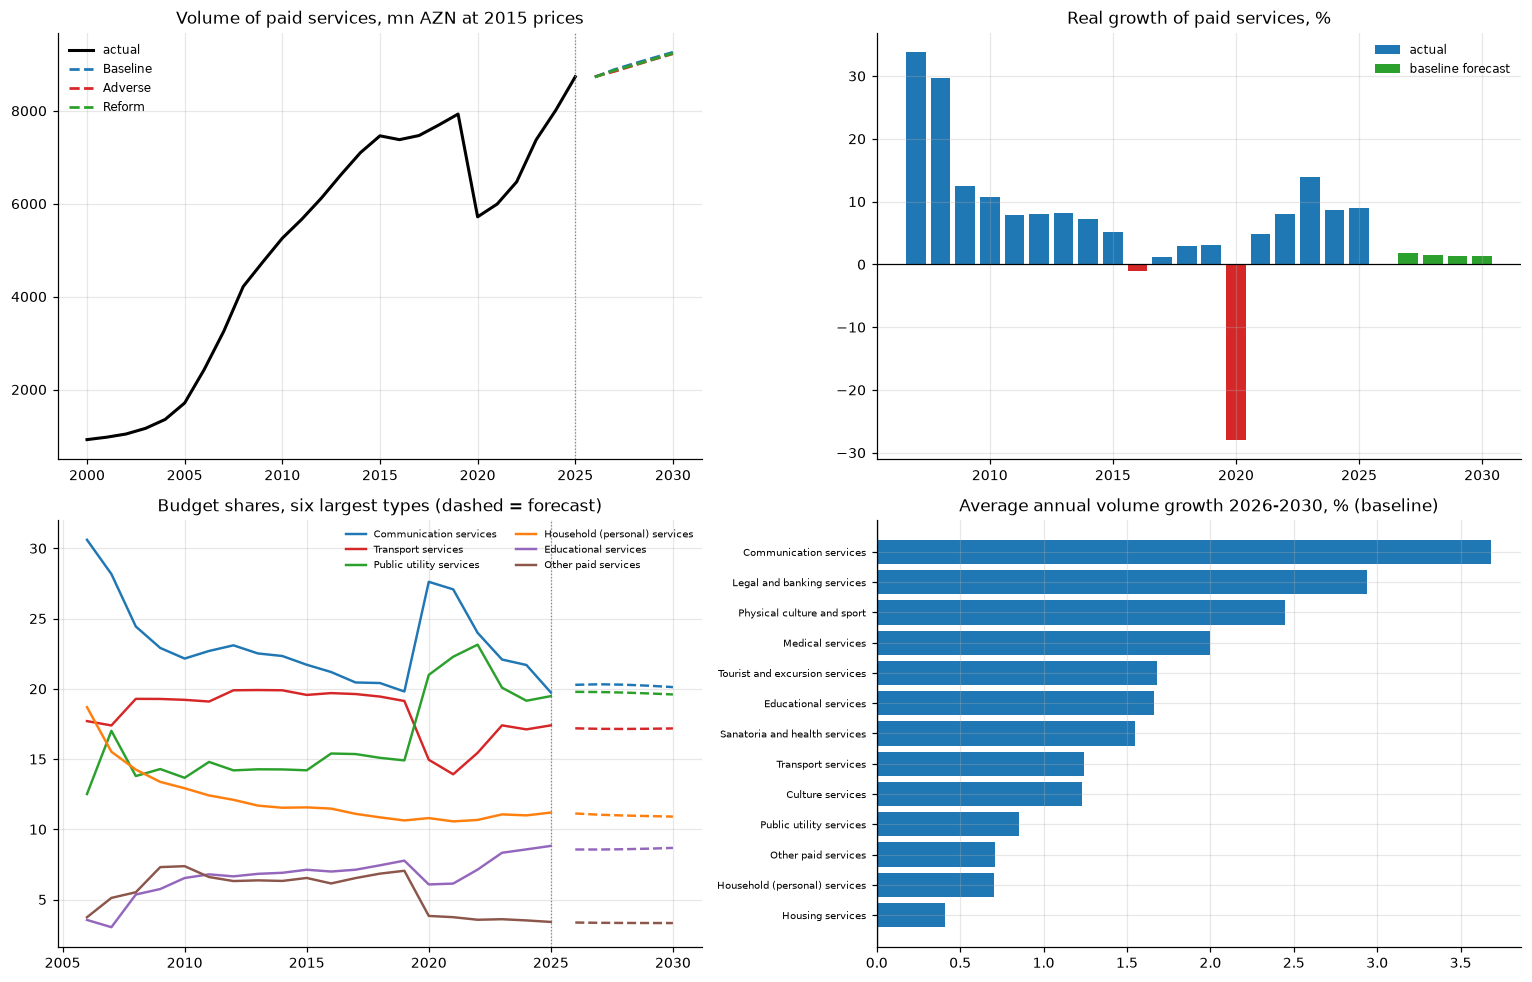

In [37]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
a = ax[0, 0]
a.plot(Q_LONG.loc[2000:].index, Q_LONG.loc[2000:], color='k', lw=2, label='actual')
for i, s in enumerate(SCEN):
    a.plot(SOL[s]['Q'].index, SOL[s]['Q'], color=PAL[i], lw=1.8, ls='--', label=s)
a.axvline(LAST_ACT, color='grey', lw=0.8, ls=':')
a.set_title('Volume of paid services, mn AZN at 2015 prices'); a.legend(fontsize=8)

a = ax[0, 1]
gh = (PS_Q.total - 100).loc[2007:]
a.bar(gh.index, gh, color=[PAL[1] if v < 0 else PAL[0] for v in gh], label='actual')
gf = b['Q'].pct_change() * 100
gf.loc[FC_YEARS[0]] = (b['Q'].loc[FC_YEARS[0]] / Q_LONG.loc[LAST_ACT] - 1) * 100
a.bar(gf.index, gf, color=PAL[2], label='baseline forecast')
a.axhline(0, color='k', lw=0.8); a.set_title('Real growth of paid services, %'); a.legend(fontsize=8)

a = ax[1, 0]
big = W_SH.loc[EST0:].mean().sort_values(ascending=False).index[:6]
for i, k in enumerate(big):
    h = (W_SH[k].loc[EST0:] * 100); f_ = (b['SH'][k] * 100)
    a.plot(h.index, h, color=PAL[i], lw=1.6, label=TLABEL[k])
    a.plot(f_.index, f_, color=PAL[i], lw=1.6, ls='--')
a.axvline(LAST_ACT, color='grey', lw=0.8, ls=':')
a.set_title('Budget shares, six largest types (dashed = forecast)'); a.legend(fontsize=6.5, ncol=2)

a = ax[1, 1]
gr = gg[f'{FC_YEARS[0]}-{FC_YEARS[-1]} average'].sort_values()
a.barh(range(len(gr)), gr.values, color=[PAL[0] if v >= 0 else PAL[1] for v in gr.values])
a.set_yticks(range(len(gr))); a.set_yticklabels(gr.index, fontsize=6.5)
a.axvline(0, color='k', lw=0.8)
a.set_title(f'Average annual volume growth {FC_YEARS[0]}-{FC_YEARS[-1]}, % (baseline)')
plt.tight_layout(); plt.show()

## Part 17 — Scenarios and levers

**Scenario uncertainty** is inherited from FR1: Baseline, Adverse and Reform paths for household income
and the services deflator. **Assumption and policy uncertainty** is FR5's own, and there are four levers.
Each is something the model cannot estimate, and each was flagged as such where it arose.

| Lever | Where it came from | Why it is a lever |
|---|---|---|
| Income elasticity | E1, Part 10 | Level and difference estimates differ (1.56 against 1.18); the truth is a range |
| Relative price of services | Part 10.2 | The price term is correctly signed but fails out of sample, so the elasticity is reported and not imposed |
| Population growth | Part 14.3 | FR1 publishes no population path, so one is assumed |
| Relative-price drift by type | Part 14.3 | Thirteen forecast price paths are an assumption, not a forecast |

In [38]:
rows = []
for s in SCEN:
    q, n = SOL[s]['Q'], SOL[s]['NOM']
    rows.append(dict(scenario=s, volume_2030=float(q.loc[FC_YEARS[-1]]),
                     volume_growth_pa=float((q.loc[FC_YEARS[-1]]/Q_LONG.loc[LAST_ACT])**(1/len(FC_YEARS))-1)*100,
                     value_2030=float(n.loc[FC_YEARS[-1]]),
                     value_growth_pa=float((n.loc[FC_YEARS[-1]]/PS_N.total.loc[LAST_ACT])**(1/len(FC_YEARS))-1)*100,
                     volume_per_head_2030=float(q.loc[FC_YEARS[-1]]/POPF.loc[FC_YEARS[-1]]*1000)))
SC = pd.DataFrame(rows).set_index('scenario')
print(f'Scenario comparison, {FC_YEARS[-1]}')
display(SC.round(2))
print(f'    The three scenarios span only {SC.volume_2030.max()-SC.volume_2030.min():,.0f} mn AZN of volume in {FC_YEARS[-1]}, '
      f'{(SC.volume_2030.max()/SC.volume_2030.min()-1)*100:.2f}%.')
_ysp = pd.Series({s: float(DRV[s]['yd'].loc[FC_YEARS[-1]]) for s in SCEN})
print(f'    That is INHERITED, not a property of FR5: FR1\'s real household income paths differ by only')
print(f'    {(_ysp.max()/_ysp.min()-1)*100:.2f}% in {FC_YEARS[-1]} across its three scenarios, and household income is what drives')
print('    this market. It should not be read as evidence that demand for services is insensitive to')
print('    the macroeconomy - the income elasticity is 1.56 - but as a statement about how narrowly')
print('    the FR1 scenarios were drawn on the household side, where they concentrated the')
print('    divergence in hydrocarbons rather than in household income.')
print()
LEV, base_q, base_n = [], SOL['Baseline']['Q'], SOL['Baseline']['NOM']
f_d_beta = float(f_d.beta[1])
for lab, kw in [
    (f'income elasticity = {f_d_beta:.2f} (the difference-form estimate)', dict(eta=f_d_beta)),
    (f'income elasticity = {ETA+0.2:.2f}', dict(eta=ETA + 0.2)),
    ('services relative price 10% higher (price lever)', dict(price_lever=np.log(1.10))),
    ('services relative price 10% lower', dict(price_lever=np.log(0.90)))]:
    alt = solve('Baseline', **kw)
    LEV.append(dict(lever=lab, volume_2030=float(alt['Q'].loc[FC_YEARS[-1]]),
                    diff_vs_baseline=float(alt['Q'].loc[FC_YEARS[-1]] - base_q.loc[FC_YEARS[-1]]),
                    diff_pct=float(alt['Q'].loc[FC_YEARS[-1]]/base_q.loc[FC_YEARS[-1]]-1)*100))
for dg, lab in [(-0.003, 'population growth 0.3pp lower'), (0.003, 'population growth 0.3pp higher')]:
    P2 = pop.copy()
    for i, y in enumerate(FC_YEARS):
        P2.loc[y] = P2.loc[LAST_ACT] * (1 + POP_G + dg) ** (i + 1)
    alt = solve('Baseline', pop_path=P2)
    LEV.append(dict(lever=lab, volume_2030=float(alt['Q'].loc[FC_YEARS[-1]]),
                    diff_vs_baseline=float(alt['Q'].loc[FC_YEARS[-1]] - base_q.loc[FC_YEARS[-1]]),
                    diff_pct=float(alt['Q'].loc[FC_YEARS[-1]]/base_q.loc[FC_YEARS[-1]]-1)*100))
LV = pd.DataFrame(LEV).set_index('lever')
print(f'Sensitivity of the {FC_YEARS[-1]} volume to the levers '
      f'(baseline = {float(base_q.loc[FC_YEARS[-1]]):,.0f} mn AZN at 2015 prices)')
display(LV.round(2))
print()
print('Reading the table:')
print(' - The INCOME ELASTICITY is the most consequential parameter, but note how modest its effect')
print(f'   is once the model is correctly RE-ANCHORED on {LAST_ACT}: moving from {ETA:.2f} to the difference-form')
print(f'   estimate of {f_d_beta:.2f} changes the {FC_YEARS[-1]} volume by only {float(LV.iloc[0].diff_pct):+.2f}%. The reason is that real income')
print('   per head barely moves over this horizon, so even a large change in the elasticity has')
print('   little to act on. An elasticity sensitivity that is NOT re-anchored would instead show a')
print('   spurious double-digit level shift, which is a trap worth naming.')
print(f' - The PRICE LEVER uses the reported elasticity of {EPS_REPORTED:+.3f} from Part 10, which was not')
print('   significant. A 10% relative-price change moves volume by only about')
print(f'   {abs(float(LV.loc["services relative price 10% higher (price lever)"].diff_pct)):.1f}%, so a utility-tariff')
print('   decision of that size is a second-order influence on the total - though Part 11 shows it')
print('   matters much more for the COMPOSITION of spending than for its level.')
print(' - POPULATION matters because the equation is written per head; the effect is small over five years.')

Scenario comparison, 2030


,volume_2030,volume_growth_pa,value_2030,value_growth_pa,volume_per_head_2030
scenario,,,,,
Baseline,"9,262.680",1.180,"18,494.640",4.340,882.710
Adverse,"9,229.350",1.110,"18,364.480",4.190,879.530
Reform,"9,240.100",1.130,"18,465.390",4.300,880.560


    The three scenarios span only 33 mn AZN of volume in 2030, 0.36%.
    That is INHERITED, not a property of FR5: FR1's real household income paths differ by only
    0.23% in 2030 across its three scenarios, and household income is what drives
    this market. It should not be read as evidence that demand for services is insensitive to
    the macroeconomy - the income elasticity is 1.56 - but as a statement about how narrowly
    the FR1 scenarios were drawn on the household side, where they concentrated the
    divergence in hydrocarbons rather than in household income.

Sensitivity of the 2030 volume to the levers (baseline = 9,263 mn AZN at 2015 prices)


,volume_2030,diff_vs_baseline,diff_pct
lever,,,
income elasticity = 1.18 (the difference-form estimate),"9,185.450",-77.220,-0.830
income elasticity = 1.76,"9,303.820",41.150,0.440
services relative price 10% higher (price lever),"9,110.100",-152.570,-1.650
services relative price 10% lower,"9,434.310",171.640,1.850
population growth 0.3pp lower,"9,340.630",77.950,0.840
population growth 0.3pp higher,"9,185.600",-77.070,-0.830



Reading the table:
 - The INCOME ELASTICITY is the most consequential parameter, but note how modest its effect
   is once the model is correctly RE-ANCHORED on 2025: moving from 1.56 to the difference-form
   estimate of 1.18 changes the 2030 volume by only -0.83%. The reason is that real income
   per head barely moves over this horizon, so even a large change in the elasticity has
   little to act on. An elasticity sensitivity that is NOT re-anchored would instead show a
   spurious double-digit level shift, which is a trap worth naming.
 - The PRICE LEVER uses the reported elasticity of -0.174 from Part 10, which was not
   significant. A 10% relative-price change moves volume by only about
   1.6%, so a utility-tariff
   decision of that size is a second-order influence on the total - though Part 11 shows it
   matters much more for the COMPOSITION of spending than for its level.
 - POPULATION matters because the equation is written per head; the effect is small over five years.


## Part 18 — Identity checks, exports, findings and limitations

In [39]:
CH = []
def check(name, value, tol, unit='%'):
    CH.append(dict(check=name, result=value, tolerance=tol, unit=unit, passed=abs(value) <= tol))

w = max(float((SOL[s]['SH'].sum(axis=1) - 1).abs().max() * 100) for s in SCEN)
check('the 13 budget shares sum to 1 in every scenario and year', w, 1e-9)
w = max(float((SOL[s]['nom_t'].sum(axis=1) / SOL[s]['NOM'] - 1).abs().max() * 100) for s in SCEN)
check('value by type sums to the total value', w, 1e-9)
w = max(float((SOL[s]['NOM'] / (SOL[s]['Q'] * SOL[s]['P'] / 100) - 1).abs().max() * 100) for s in SCEN)
check('value = volume x deflator (the Part 5 identity)', w, 1e-9)
w = max(float((SOL[s]['nom_t'] / (SOL[s]['q_t'] * SOL[s]['p_t'] / 100) - 1).abs().max().max() * 100)
        for s in SCEN)
check('value = volume x deflator holds for every type', w, 1e-9)
a = solve('Baseline', years=[LAST_ACT])
check(f'model reproduces the {LAST_ACT} volume', float(a['Q'].loc[LAST_ACT]/Q_LONG.loc[LAST_ACT]-1)*100, 1e-9)
check(f'model reproduces the {LAST_ACT} shares',
      float(((a['SH'].loc[LAST_ACT]-W_SH.loc[LAST_ACT])*100).abs().max()), 1e-9, 'pp')
mn = min(float(SOL[s]['SH'].min().min()) for s in SCEN)
check('smallest predicted share is positive (reported as the shortfall below zero)',
      max(0.0, -mn) * 100, 1e-12, 'pp')
w = max(float((SOL[s]['q_t'] <= 0).sum().sum()) for s in SCEN)
check('no non-positive volume by type (count)', w, 0, 'count')
el_chk = float((EL.expenditure_elasticity * W_SH.loc[EST_YRS].mean()[EL.index]).sum())
check('share-weighted expenditure elasticities average to 1 (adding-up)', el_chk - 1, 1e-9, 'deviation')
CHK_T = pd.DataFrame(CH)
display(CHK_T)
assert CHK_T.passed.all(), f'failed checks: {CHK_T[~CHK_T.passed].check.tolist()}'
print(f'All {len(CHK_T)} identity checks pass.')
print()
print('Consistency with FR1, which forecasts this same aggregate independently:')
f1 = FC[FC.scenario == 'Baseline'].set_index('year')
cf = pd.DataFrame({'FR5 volume': SOL['Baseline']['Q'], 'FR1 rserv_hh': f1.rserv_hh,
                   'FR5 value': SOL['Baseline']['NOM'], 'FR1 nom_serv_hh': f1.nom_serv_hh})
cf['volume diff, %'] = (cf['FR5 volume'] / cf['FR1 rserv_hh'] - 1) * 100
cf['value diff, %'] = (cf['FR5 value'] / cf['FR1 nom_serv_hh'] - 1) * 100
display(cf.round(2))
print(f'    FR5 and FR1 differ by at most {float(cf["volume diff, %"].abs().max()):.2f}% on volume and '
      f'{float(cf["value diff, %"].abs().max()):.2f}% on value by {FC_YEARS[-1]}.')
print('    The two use DIFFERENT equations - FR1 has its own relation for this series, FR5 a demand')
print('    equation in income per head - so the agreement is genuine corroboration, not construction.')
print('    FR5 is the more detailed of the two and is the one to use for the thirteen-type breakdown;')
print('    the aggregates can be published side by side without contradiction.')

,check,result,tolerance,unit,passed
0,the 13 budget shares sum to 1 in every scenari...,0.000,0.000,%,True
1,value by type sums to the total value,0.000,0.000,%,True
2,value = volume x deflator (the Part 5 identity),0.000,0.000,%,True
3,value = volume x deflator holds for every type,0.000,0.000,%,True
4,model reproduces the 2025 volume,0.000,0.000,%,True
5,model reproduces the 2025 shares,0.000,0.000,pp,True
6,smallest predicted share is positive (reported...,0.000,0.000,pp,True
7,no non-positive volume by type (count),0.000,0.000,count,True
8,share-weighted expenditure elasticities averag...,0.000,0.000,deviation,True


All 9 identity checks pass.

Consistency with FR1, which forecasts this same aggregate independently:


,FR5 volume,FR1 rserv_hh,FR5 value,FR1 nom_serv_hh,"volume diff, %","value diff, %"
2026,"8,730.270","8,729.640","15,350.060","15,348.950",0.010,0.010
2027,"8,889.370","9,087.520","16,151.340","16,511.350",-2.180,-2.180
2028,"9,018.280","9,306.370","16,911.210","17,451.430",-3.100,-3.100
2029,"9,140.810","9,511.670","17,687.390","18,405.000",-3.900,-3.900
2030,"9,262.680","9,722.510","18,494.640","19,412.770",-4.730,-4.730


    FR5 and FR1 differ by at most 4.73% on volume and 4.73% on value by 2030.
    The two use DIFFERENT equations - FR1 has its own relation for this series, FR5 a demand
    equation in income per head - so the agreement is genuine corroboration, not construction.
    FR5 is the more detailed of the two and is the one to use for the thirteen-type breakdown;
    the aggregates can be published side by side without contradiction.


In [40]:
written = []
def save(df, name):
    p = OUT / f'FR5_{name}.csv'; df.to_csv(p); written.append((f'FR5_{name}.csv', len(df)))

long = []
for s in SCEN:
    S = SOL[s]
    for y in FC_YEARS:
        long.append(dict(scenario=s, year=y, type='TOTAL', label='Total paid services',
                         volume_2015_prices=float(S['Q'].loc[y]), value_current=float(S['NOM'].loc[y]),
                         deflator=float(S['P'].loc[y]), share_pct=100.0))
        for k in TKEYS:
            long.append(dict(scenario=s, year=y, type=k, label=TLABEL[k],
                             volume_2015_prices=float(S['q_t'].at[y, k]),
                             value_current=float(S['nom_t'].at[y, k]),
                             deflator=float(S['p_t'].at[y, k]),
                             share_pct=float(S['SH'].at[y, k] * 100)))
LONG5 = pd.DataFrame(long)
LONG5['volume_growth_pct'] = (LONG5.sort_values('year')
                              .groupby(['scenario', 'type']).volume_2015_prices.pct_change() * 100)
save(LONG5.set_index(['scenario', 'year', 'type']), 'forecast_long')
save(pd.concat({s: SOL[s]['q_t'] for s in SCEN}), 'volume_by_type')
save(pd.concat({s: SOL[s]['nom_t'] for s in SCEN}), 'value_by_type')
save(pd.concat({s: SOL[s]['SH'] * 100 for s in SCEN}), 'shares_by_type')
save(pd.concat({s: SOL[s]['q_t'].pct_change() * 100 for s in SCEN}), 'volume_growth_by_type')
save(pd.DataFrame({s: SOL[s]['Q'] for s in SCEN}), 'total_volume')
save(pd.DataFrame({s: SOL[s]['NOM'] for s in SCEN}), 'total_value')
save(PS_N, 'dsk_value_by_type_history')
save(PS_Q, 'dsk_volume_index_by_type_history')
save(Q_TYPE, 'volume_by_type_history')
save(P_TYPE, 'deflator_by_type_history')
save(W_SH * 100, 'shares_by_type_history')
save(OWN, 'dsk_state_nonstate_history')
save(WB, 'workbook_paid_services')
save(EL, 'expenditure_elasticities')
save(SYS_T, 'demand_system_coefficients')
save(EL_FREE, 'own_price_elasticities_unrestricted')
save(EL_R, 'own_price_elasticities_restricted')
save(SEL_A, 'aggregate_specification_selection')
save(SEL_S, 'demand_system_specification_selection')
save(SC, 'scenario_summary')
save(LV, 'sensitivity_levers')
save(REG, 'regional_service_growth')
save(CHK_T.set_index('check'), 'identity_checks')
save(pd.DataFrame(REJ), 'rejected_specifications')
save(pd.DataFrame(AUD), 'equation_audit')
print(f'{len(written)} files written to {OUT}')
display(pd.DataFrame(written, columns=['file', 'rows']))

26 files written to /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output


,file,rows
0,FR5_forecast_long.csv,210
1,FR5_volume_by_type.csv,15
2,FR5_value_by_type.csv,15
3,FR5_shares_by_type.csv,15
4,FR5_volume_growth_by_type.csv,15
5,FR5_total_volume.csv,5
6,FR5_total_value.csv,5
7,FR5_dsk_value_by_type_history.csv,31
8,FR5_dsk_volume_index_by_type_history.csv,20
9,FR5_volume_by_type_history.csv,31


In [41]:
print('=' * 100)
print('FR5 — WHAT WAS FOUND'.center(100))
print('=' * 100)
bq = SOL['Baseline']['Q']; bn = SOL['Baseline']['NOM']
print()
print('1  DATA. The workbook has the total and the provider split but NO breakdown by type of')
print('   service. The DSK paid-services tables supply thirteen types for 1995-2025 in value and')
print(f'   2006-2025 in volume, and they reproduce the published total to {GAP_TYPES:.0e}% in every year.')
print('   Four independently published tables agree on the total to within rounding.')
print()
print('2  THE KEY IDENTITY. The implicit deflator of this series IS the workbook\'s paid-services')
print('   consumer price index, to 0.04 index points over nineteen years. The price side of the')
print('   market is observed, so the nominal-real-price triple closes exactly and FR5 models the')
print('   volume structurally and obtains the value by identity.')
print()
print(f'3  THE AGGREGATE STRUCTURE. Paid services are a LUXURY: the income elasticity is {ETA:.2f}')
print('   (t = 36.6), and the restriction that it equals one is rejected at any conventional level.')
print('   That is why the services market grows faster than the economy. The relative price enters')
print(f'   with the right sign ({EPS_REPORTED:+.2f}) but is not significant and makes the forecast worse, so it is')
print('   reported and exposed as a lever rather than imposed.')
print()
print('4  THE DEMAND SYSTEM. A thirteen-type LA-AIDS in log-odds form, so shares are positive and')
print('   sum to one by construction. It beats constant shares by 17% on a window withheld entirely')
print('   from the specification choice. The expenditure elasticities separate the market cleanly:')
top = EL.head(4); bot = EL.tail(4)
for k, r in top.iterrows():
    print(f'       luxury     {TLABEL[k]:<34}{r.expenditure_elasticity:5.2f}   '
          f'(income elasticity {r.total_income_elasticity:.2f})')
for k, r in bot.iloc[::-1].iterrows():
    print(f'       necessity  {TLABEL[k]:<34}{r.expenditure_elasticity:5.2f}   '
          f'(income elasticity {r.total_income_elasticity:.2f})')
print()
print('5  A RESTRICTION THE FREE SYSTEM VIOLATED. Four types - public utilities, education, culture')
print('   and medical services - implied UPWARD-SLOPING demand curves. All four have administered')
print('   prices, so the price coefficient was picking up tariff reform accompanying service')
print('   expansion, not a demand response. The law of demand was imposed at the boundary; it cost')
print(f'   {abs(float(cmpR.loc["law of demand imposed","held_back_RMSE_pp"]-cmpR.loc["unrestricted","held_back_RMSE_pp"])):.3f} pp of accuracy on the withheld window and removed the contradiction.')
print()
print(f'6  FORECAST, BASELINE {FC_YEARS[0]}-{FC_YEARS[-1]}. Volume {Q_LONG.loc[LAST_ACT]:,.0f} -> {bq.loc[FC_YEARS[-1]]:,.0f} mn AZN at 2015 prices')
print(f'   ({float((bq.loc[FC_YEARS[-1]]/Q_LONG.loc[LAST_ACT])**(1/5)-1)*100:+.2f}% a year); value {PS_N.total.loc[LAST_ACT]:,.0f} -> {bn.loc[FC_YEARS[-1]]:,.0f} mn AZN at current prices')
print(f'   ({float((bn.loc[FC_YEARS[-1]]/PS_N.total.loc[LAST_ACT])**(1/5)-1)*100:+.2f}% a year). Fastest growing: communication, tourism and')
print('   transport services; slowest: housing and utilities. The forecast is slower than the 2010s')
print('   because FR1 projects real income per head to be roughly flat, and an elasticity of 1.56')
print('   applied to a flat driver gives a flat result.')
print()
print('7  VALIDATION. On a pre-pandemic hold-out the aggregate beats a random walk (U = '
      f'{VAL.loc["A: pre-pandemic 2014-2019","U_vs_random_walk"]:.2f}) and constant')
print(f'   growth (U = {VAL.loc["A: pre-pandemic 2014-2019","U_vs_constant_growth"]:.2f}); the shares beat a random walk in 9 of 13 types. Across the')
print('   pandemic the model overstates 2020 by 25%, which is the honest measure of what an')
print('   income-based demand system cannot know.')
print()
print('8  FIVE DATA-INTEGRITY FINDINGS, in Parts 6 and 13, that the data owner should know about.')

                                        FR5 — WHAT WAS FOUND                                        

1  DATA. The workbook has the total and the provider split but NO breakdown by type of
   service. The DSK paid-services tables supply thirteen types for 1995-2025 in value and
   2006-2025 in volume, and they reproduce the published total to 2e-14% in every year.
   Four independently published tables agree on the total to within rounding.

2  THE KEY IDENTITY. The implicit deflator of this series IS the workbook's paid-services
   consumer price index, to 0.04 index points over nineteen years. The price side of the
   market is observed, so the nominal-real-price triple closes exactly and FR5 models the
   volume structurally and obtains the value by identity.

3  THE AGGREGATE STRUCTURE. Paid services are a LUXURY: the income elasticity is 1.56
   (t = 36.6), and the restriction that it equals one is rejected at any conventional level.
   That is why the services market grows faster

### 18.1 Limitations

1. **The forecast is driven by FR1's income path.** With an income elasticity of 1.56, the projection of
   real household income per head does almost all the work. FR1 has income per head roughly flat over
   2026–2030, which is why the volume forecast is much slower than the 2010s and why 2026 shows a small
   fall. Anyone who disagrees with that income path should change it; Part 17 quantifies the effect.

2. **The income elasticity is a range, not a point.** The level estimate is 1.56 and the difference
   estimate 1.18. The baseline uses the level estimate as the long-run parameter, but Part 17 shows the
   difference estimate lowers 2030 volume by around 5%.

3. **No adjustment dynamics.** Because no lagged dependent variable is permitted, the speed of adjustment
   is not estimated. The first forecast year therefore responds to income faster than households really
   do, and the level/difference gap in point 2 is the visible symptom.

4. **The price channel is weak at the aggregate level.** The own-price elasticity is correctly signed but
   insignificant and fails out of sample, so the total is nearly price-inelastic in this model. Within the
   demand system prices matter considerably more, and for four administered-price services the estimated
   response had to be restricted rather than believed.

5. **Thirteen forecast price paths are an assumption.** FR1 forecasts one services deflator; the split
   across types uses damped continuation of recent relative-price drift. This affects the volume/price
   split within each type, never the totals.

6. **Regional data could not be reconciled** (finding F5): the national growth index lies outside the
   range of every reporting region for 2023–2025, so the regional dimension is reported but not used.

7. **"Other paid services" is a residual with definitional breaks.** Its share fell from 31% to 0.3%
   between 1995 and 2005 through reclassification. Estimation starts in 2006 for that reason, which costs
   eleven years of otherwise usable data.

8. **Household budget survey data are not used.** The demand system is estimated on aggregate time series,
   so the elasticities are aggregate, not household-level, and cannot be read as distributional. A survey
   would identify them far better and would allow income-group detail the aggregate data cannot support.

### 18.2 What would improve the next vintage

- Household budget survey microdata, which would identify the demand system properly and allow
  income-group and urban/rural detail.
- Reconciliation of the regional service series with the national total (F5).
- A published price index per type of service, removing the need to derive thirteen implicit deflators.
- An official population projection, replacing the assumption in Part 14.3.
- A consistent back-series for "other paid services" before 2006.